In [1]:
# !pip install pandas numpy scikit-learn matplotlib datasets pyarrow
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option("display.max_colwidth", 50)
print("Setup selesai.")

Setup selesai.


In [2]:
df = pd.read_parquet("video_games_kcore.parquet")        # sebelum cleaning (994rb)
df_clean = pd.read_parquet("video_games_clean.parquet")  # sesudah cleaning (964rb)

print("Sebelum cleaning:", df.shape)
print("Sesudah cleaning:", df_clean.shape)
print(f"Baris yang dibuang: {len(df) - len(df_clean):,} (duplikat + judul kosong)")

Sebelum cleaning: (994883, 9)
Sesudah cleaning: (964834, 9)
Baris yang dibuang: 30,049 (duplikat + judul kosong)


In [3]:
pd.set_option("display.max_columns", None)      # tampilkan semua kolom
pd.set_option("display.width", None)            # lebar tak terbatas
df_clean.head()

,user_id,parent_asin,rating,timestamp,product_title,description,features,categories,price
0,AHV2HBORH6QV3PYLTKF3CADFPOFA,B00000DMAM,5,1999-10-22 21:43:15,Unreal (Jewel Case) - PC,"Amazon.com You awaken in a small, enclosed roo...",,Video Games PC Games,17.50
1,AFNDV7E4UQPFVGTNBVRPWP5EBSZQ,B00002NDRY,4,1999-11-05 18:04:22,Age of Empires 2: Age of Kings - PC,Product description Age of Empires II: Age of ...,You will take an ancient people through a 1000...,Video Games PC Games,64.88
2,AGNINTA35XXMBXGN7IBCUIFCS3WQ,B00000K1V2,2,1999-11-10 18:29:51,South Park - PlayStation,"Amazon.com Cartman, Kyle, Stan, and Kenny hop ...",Disc(s) plus hard plastic protective replaceme...,Video Games Legacy Systems PlayStation Systems...,53.99
3,AGNINTA35XXMBXGN7IBCUIFCS3WQ,B000021Y5V,3,1999-11-10 18:41:12,San Francisco Rush Extreme Racing,Product description PlayStation ~ San Francisc...,,Video Games Legacy Systems PlayStation Systems...,24.99
4,AGNINTA35XXMBXGN7IBCUIFCS3WQ,B000021Y5F,5,1999-11-10 18:55:17,William's Arcade's Greatest Hits,From the Manufacturer Some of the greatest arc...,Robotron: 2004,Video Games Legacy Systems PlayStation Systems...,49.77


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
PRIMARY = "#2563eb"; MUTED = "#cbd5e1"; ACCENT = "#f59e0b"

# pastikan df_clean ada (kalau kernel habis restart)
# df_clean = pd.read_parquet("video_games_clean.parquet")
df_clean["tahun"] = pd.to_datetime(df_clean["timestamp"]).dt.year

### Distribusi Rating

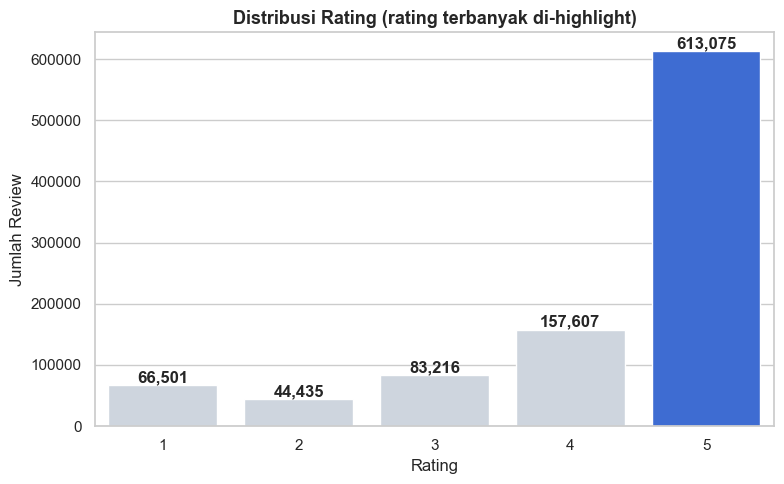

In [5]:
rating_dist = df_clean["rating"].value_counts().sort_index()
mx = rating_dist.idxmax()
colors = [PRIMARY if r == mx else MUTED for r in rating_dist.index]

plt.figure(figsize=(8,5))
ax = sns.barplot(x=rating_dist.index.astype(str), y=rating_dist.values, palette=colors)
for i, v in enumerate(rating_dist.values):
    ax.text(i, v, f"{int(v):,}", ha="center", va="bottom", fontweight="bold")
plt.title("Distribusi Rating (rating terbanyak di-highlight)", fontsize=13, fontweight="bold")
plt.xlabel("Rating"); plt.ylabel("Jumlah Review")
plt.tight_layout(); plt.show()

**Insight**: Distribusi rating sangat condong ke nilai tinggi — rating 5 mendominasi (613.075, ~64% dari total), membentuk pola J-shaped yang khas pada data review e-commerce. Ini menunjukkan bias positif: user cenderung memberi rating saat sangat puas, sementara pengalaman biasa-biasa saja jarang di-review. Implikasinya, rating tinggi adalah norma, sehingga sinyal rating rendah (1-2) justru lebih membedakan untuk mengidentifikasi produk yang kurang disukai.

### Sparsity (kenapa recommender dibutuhkan)

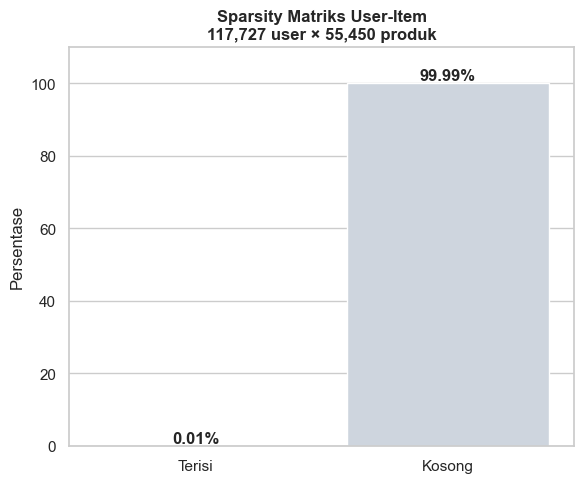

Sparsity: 99.9852% — hanya 0.015% kombinasi user-produk yang punya interaksi


In [6]:
n_u = df_clean["user_id"].nunique()
n_i = df_clean["parent_asin"].nunique()
n_x = len(df_clean)
sparsity = (1 - n_x/(n_u*n_i)) * 100

plt.figure(figsize=(6,5))
ax = sns.barplot(x=["Terisi","Kosong"], y=[100-sparsity, sparsity],
                 palette=[PRIMARY, MUTED])
for i, v in enumerate([100-sparsity, sparsity]):
    ax.text(i, v, f"{v:.2f}%", ha="center", va="bottom", fontweight="bold")
plt.title(f"Sparsity Matriks User-Item\n{n_u:,} user × {n_i:,} produk", fontsize=12, fontweight="bold")
plt.ylabel("Persentase"); plt.ylim(0,110)
plt.tight_layout(); plt.show()
print(f"Sparsity: {sparsity:.4f}% — hanya {100-sparsity:.3f}% kombinasi user-produk yang punya interaksi")

Insight: Matriks user-item sangat sparse (>99,9% kosong) — hanya sebagian kecil kombinasi user-produk yang memiliki interaksi nyata. Inilah alasan fundamental sistem rekomendasi dibutuhkan: setiap user hanya menyentuh sebagian kecil katalog, sehingga sistem harus memprediksi produk relevan dari sedikit data yang ada.

### Distribusi aktivitas user (long tail)

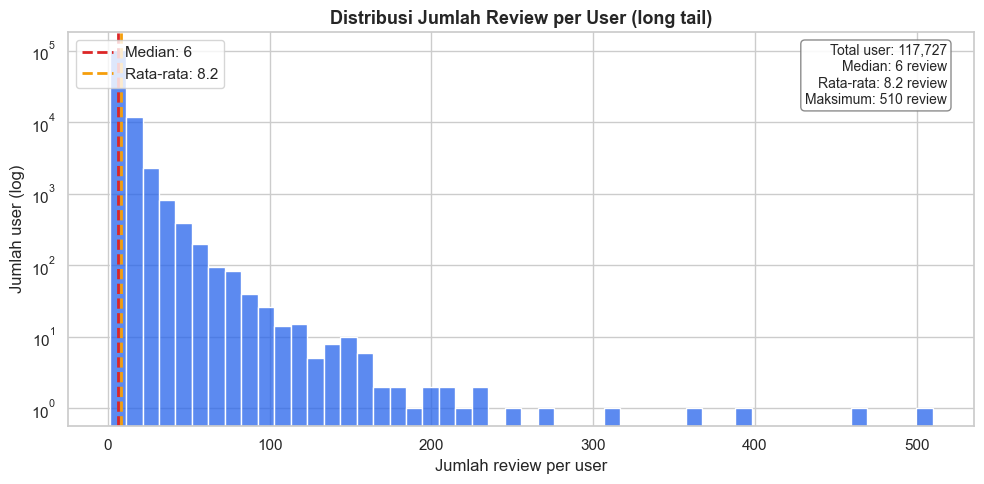

In [7]:
user_act = df_clean["user_id"].value_counts()
median_val = user_act.median()
mean_val = user_act.mean()
max_val = user_act.max()

plt.figure(figsize=(10,5))
ax = sns.histplot(user_act.values, bins=50, color="#2563eb")
plt.yscale("log")

# Garis median (merah) & rata-rata (oranye) — kontras kuat di atas bar biru
plt.axvline(median_val, color="#dc2626", linestyle="--", linewidth=2, label=f"Median: {median_val:.0f}")
plt.axvline(mean_val, color="#f59e0b", linestyle="--", linewidth=2, label=f"Rata-rata: {mean_val:.1f}")

# Kotak teks statistik di pojok
stats_text = (f"Total user: {len(user_act):,}\n"
              f"Median: {median_val:.0f} review\n"
              f"Rata-rata: {mean_val:.1f} review\n"
              f"Maksimum: {max_val:,} review")
plt.text(0.97, 0.97, stats_text, transform=ax.transAxes,
         fontsize=10, va="top", ha="right",
         bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.9))

plt.title("Distribusi Jumlah Review per User (long tail)", fontsize=13, fontweight="bold")
plt.xlabel("Jumlah review per user"); plt.ylabel("Jumlah user (log)")
plt.legend(loc="upper left"); plt.tight_layout(); plt.show()

Insight: Distribusi review per user mengikuti pola long tail — mayoritas user hanya memberi sedikit review (median 6, rata-rata 8,2), sementara segelintir user sangat aktif (hingga 500+ review). Skala log digunakan untuk menampilkan kedua ekstrem ini sekaligus. Pola ini menjelaskan dua hal: (1) k-core filtering diperlukan untuk membuang user yang terlalu jarang diprofilkan, dan (2) cold-start menjadi tantangan nyata karena sistem sering menghadapi user dengan riwayat minim.

### Distribusi popularitas produk (long tail)

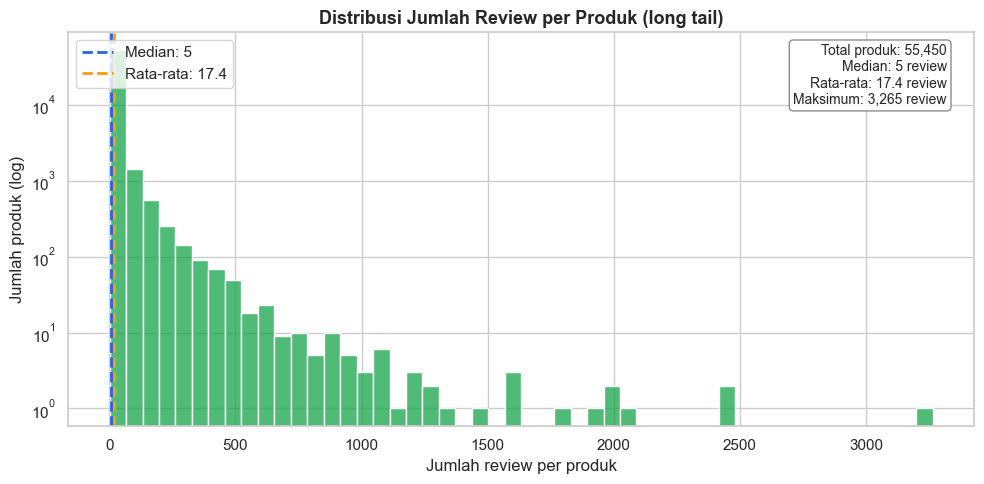

In [8]:
item_pop = df_clean["parent_asin"].value_counts()
median_val = item_pop.median()
mean_val = item_pop.mean()
max_val = item_pop.max()

plt.figure(figsize=(10,5))
ax = sns.histplot(item_pop.values, bins=50, color="#16a34a")
plt.yscale("log")

# Garis median & rata-rata
plt.axvline(median_val, color="#2563eb", linestyle="--", linewidth=2, label=f"Median: {median_val:.0f}")
plt.axvline(mean_val, color="#f59e0b", linestyle="--", linewidth=2, label=f"Rata-rata: {mean_val:.1f}")

# Kotak teks statistik di pojok
stats_text = (f"Total produk: {len(item_pop):,}\n"
              f"Median: {median_val:.0f} review\n"
              f"Rata-rata: {mean_val:.1f} review\n"
              f"Maksimum: {max_val:,} review")
plt.text(0.97, 0.97, stats_text, transform=ax.transAxes,
         fontsize=10, va="top", ha="right",
         bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.9))

plt.title("Distribusi Jumlah Review per Produk (long tail)", fontsize=13, fontweight="bold")
plt.xlabel("Jumlah review per produk"); plt.ylabel("Jumlah produk (log)")
plt.legend(loc="upper left"); plt.tight_layout(); plt.show()

Insight: Popularitas produk mengikuti pola long tail — mayoritas produk hanya menerima sedikit review (median 5, rata-rata 17,4), sementara segelintir produk sangat populer (hingga 3.265 review). Ini menegaskan dua hal: (1) rekomendasi personal lebih bernilai daripada sekadar menampilkan produk populer, karena puluhan ribu produk di "ekor" berisiko tidak pernah ditemukan; dan (2) popularitas produk berguna sebagai fallback cold-start ketika sistem belum punya cukup informasi.



### Top 15 Kategori

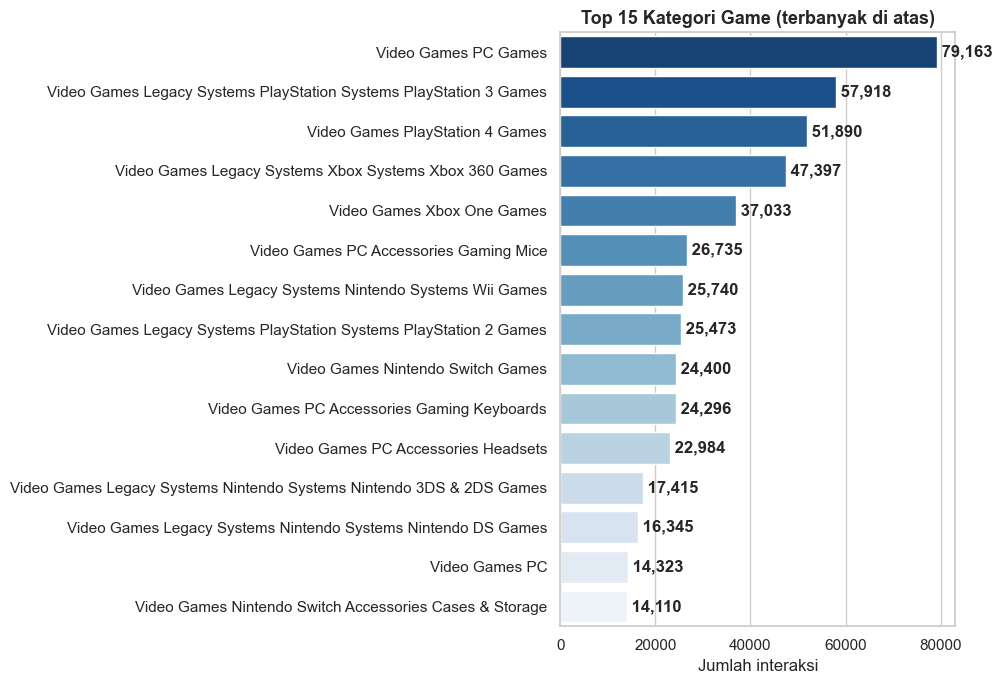

In [9]:
from collections import Counter

cat_counter = Counter()
for c in df_clean["categories"].dropna():
    for tok in str(c).split(","):
        tok = tok.strip()
        if tok and tok.lower() != "video games":
            cat_counter[tok] += 1

top_cat = pd.Series(dict(cat_counter.most_common(15))).sort_values(ascending=False)

plt.figure(figsize=(10,7))
ax = sns.barplot(x=top_cat.values, y=top_cat.index, hue=top_cat.index,
                 palette="Blues_r", legend=False)
for i, v in enumerate(top_cat.values):
    ax.text(v, i, f" {int(v):,}", va="center", fontweight="bold")
plt.title("Top 15 Kategori Game (terbanyak di atas)", fontsize=13, fontweight="bold")
plt.xlabel("Jumlah interaksi"); plt.ylabel("")
plt.tight_layout(); plt.show()

Insight: Kategori dengan interaksi terbanyak didominasi game PC (79.163 interaksi) dan konsol PlayStation (PS3: 57.918, PS4: 51.890), diikuti Xbox dan Nintendo. Terlihat dua kelompok besar: game per platform (PC, PlayStation, Xbox, Nintendo) dan aksesori (headset, keyboard, mouse gaming). Dominasi PC dan PlayStation menunjukkan basis reviewer terbesar ada di platform tersebut. Untuk content-based filtering, kategori ini menjadi salah satu fitur penting: produk dalam kategori/platform yang sama cenderung relevan untuk direkomendasikan bersama (misal, sesama game PS4, atau sesama aksesori PC).

### Top 10 Produk Terpopuler

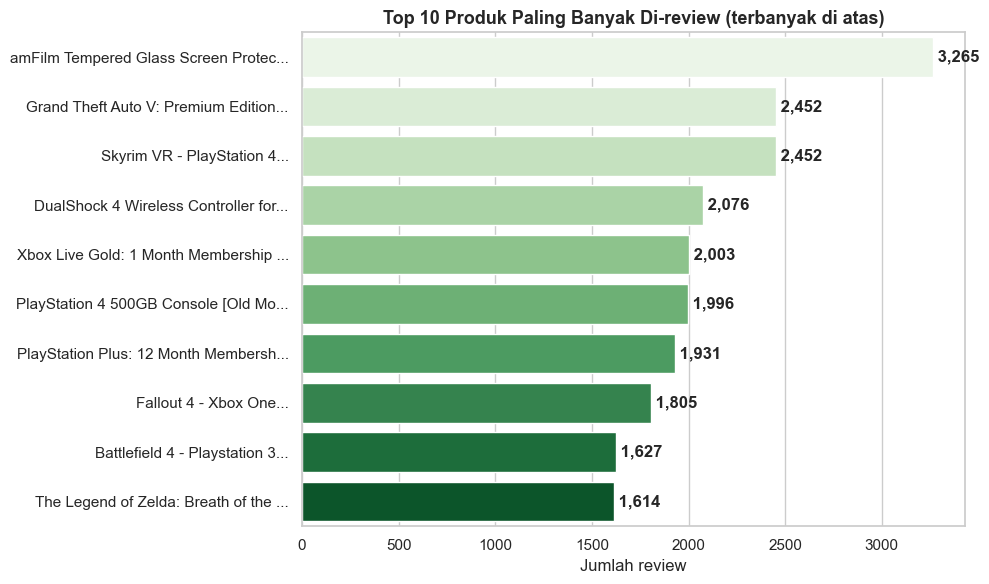

In [10]:

top_prod = (df_clean.groupby("parent_asin")
            .agg(jumlah=("rating","count"), rata=("rating","mean"),
                 judul=("product_title","first"))
            .sort_values("jumlah", ascending=False).head(10))
top_prod["judul_pendek"] = top_prod["judul"].str[:35] + "..."

# Plotting: terbesar di atas
plt.figure(figsize=(10,6))
d = top_prod.sort_values("jumlah", ascending=False)
ax = sns.barplot(x="jumlah", y="judul_pendek", data=d, hue="judul_pendek",
                 palette="Greens", legend=False)
for i, v in enumerate(d["jumlah"].values):
    ax.text(v, i, f" {int(v):,}", va="center", fontweight="bold")
plt.title("Top 10 Produk Paling Banyak Di-review (terbanyak di atas)", fontsize=13, fontweight="bold")
plt.xlabel("Jumlah review"); plt.ylabel("")
plt.tight_layout(); plt.show()

Insight: Produk paling banyak di-review didominasi aksesori dan langganan, bukan game itu sendiri. Produk teratas adalah amFilm Tempered Glass Screen Protector (3.265 review) — sebuah aksesori murah Nintendo Switch — diikuti membership (PlayStation Plus, Xbox Live Gold), controller (DualShock 4), dan konsol. Game blockbuster seperti GTA V, Skyrim VR, dan Zelda juga muncul, tetapi kalah volume dari aksesori.

Mengapa ini penting: (1) Aksesori bervolume tinggi karena dibeli lintas banyak pemilik konsol dan sering jadi pembelian berulang/pelengkap — ini sinyal kuat untuk rekomendasi "produk pelengkap". (2) Untuk baseline popularitas & cold-start fallback, produk-produk ini adalah pilihan aman karena diminati luas. (3) Namun, popularitas tinggi pada aksesori generik menunjukkan keterbatasan rekomendasi berbasis popularitas saja — merekomendasikan screen protector ke semua orang kurang personal, sehingga content-based & collaborative filtering diperlukan untuk rekomendasi yang relevan dengan minat spesifik user.

Dominasi aksesori (screen protector, controller, membership) di puncak popularitas mengonfirmasi temuan long tail sebelumnya: produk bervolume sangat tinggi cenderung generik dan lintas-pengguna, sementara game spesifik tersebar di "ekor". Ini memperkuat argumen bahwa rekomendasi personal lebih bernilai daripada sekadar menampilkan yang terpopuler karena yang terpopuler seringkali aksesori umum yang relevansinya rendah untuk preferensi individual.

### Tren Interaksi per Tahun

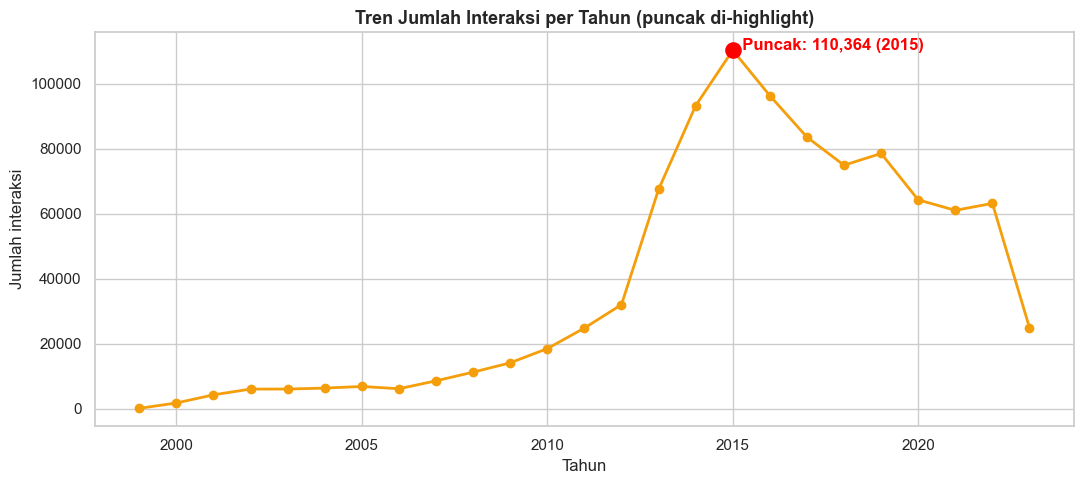

In [11]:
per_th = df_clean["tahun"].value_counts().sort_index()
puncak_th = per_th.idxmax()

plt.figure(figsize=(11,5))
plt.plot(per_th.index, per_th.values, marker="o", color=ACCENT, linewidth=2)
plt.scatter([puncak_th],[per_th.max()], color="red", s=120, zorder=5)
plt.text(puncak_th, per_th.max(), f"  Puncak: {per_th.max():,} ({puncak_th})",
         fontweight="bold", color="red")
plt.title("Tren Jumlah Interaksi per Tahun (puncak di-highlight)", fontsize=13, fontweight="bold")
plt.xlabel("Tahun"); plt.ylabel("Jumlah interaksi")
plt.tight_layout(); plt.show()



Insight: Volume interaksi menunjukkan tiga fase: pertumbuhan perlahan (2000-2012), lonjakan tajam menuju puncak 110.364 interaksi pada 2015, lalu penurunan bertahap hingga 2023. Pola ini kemungkinan mencerminkan dinamika platform Amazon (pertumbuhan basis pengguna dan budaya menulis review yang memuncak pertengahan 2010-an), bukan semata aktivitas pasar game.

Catatan penting untuk pemodelan: Penurunan tajam di tahun terakhir (2023) hampir pasti merupakan artefak pengumpulan data — dataset di-crawl pada pertengahan 2023, sehingga tahun tersebut belum lengkap, bukan berarti aktivitas benar-benar anjlok. Ini perlu disadari agar tidak salah menyimpulkan adanya "penurunan minat".

Dari sisi recommender, distribusi temporal ini menunjukkan bahwa sebagian besar interaksi terkonsentrasi pada 2013-2019. Untuk sistem berbasis konten dan kolaboratif yang dibangun di sini, aspek temporal tidak dimodelkan secara eksplisit (rekomendasi didasarkan pada kemiripan konten dan pola rating, bukan waktu), namun konteks ini berguna jika ke depan ingin menambahkan pembobotan berbasis waktu (misal, memberi bobot lebih pada interaksi terbaru).

### Kelengkapan teks untuk fitur

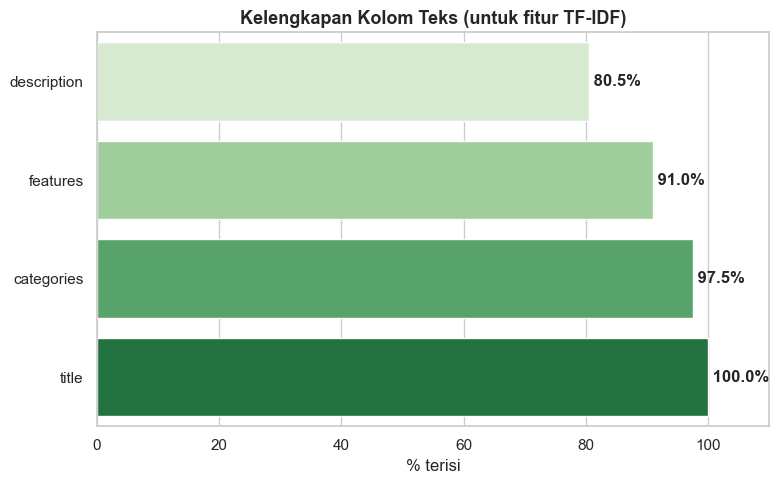

In [12]:
kelengkapan = {
    "title": (df_clean["product_title"].fillna("").str.len() >= 2).mean()*100,
    "description": (df_clean["description"].fillna("").str.len() >= 2).mean()*100,
    "features": (df_clean["features"].fillna("").str.len() >= 2).mean()*100,
    "categories": (df_clean["categories"].fillna("").str.len() >= 2).mean()*100,
}
kel = pd.Series(kelengkapan).sort_values()

plt.figure(figsize=(8,5))
ax = sns.barplot(x=kel.values, y=kel.index, palette="Greens")
for i, v in enumerate(kel.values):
    ax.text(v, i, f" {v:.1f}%", va="center", fontweight="bold")
plt.title("Kelengkapan Kolom Teks (untuk fitur TF-IDF)", fontsize=13, fontweight="bold")
plt.xlabel("% terisi"); plt.ylabel(""); plt.xlim(0,110)
plt.tight_layout(); plt.show()

Insight: Keempat kolom teks memiliki tingkat kelengkapan yang berbeda: title terisi 100%, categories 97,5%, features 91,0%, dan description 80,5%. Artinya, setiap produk selalu punya judul, tetapi sekitar 1 dari 5 produk tidak memiliki deskripsi.

Implikasi untuk pemodelan content-based: Ini membenarkan strategi menggabungkan keempat kolom menjadi satu fitur teks (title + categories + features + description) dengan title sebagai fondasi yang selalu tersedia. Dengan pendekatan ini, tidak ada produk yang kehilangan representasi fitur sepenuhnya — bahkan produk tanpa deskripsi tetap punya judul dan kategori untuk dihitung kemiripannya. Saat membangun fitur, kolom kosong cukup diisi string kosong (fillna("")) agar tidak mengganggu proses TF-IDF.



# TAHAP  - sampling untuk modeling

Tahap pemodelan menggunakan sampel 20.000 user (bukan seluruh 117.727 user) agar matriks user-item muat di memori dan proses pelatihan lebih cepat. Sampel yang sama dipakai untuk content-based maupun collaborative filtering demi konsistensi rekomendasi. Setelah sampling, k-core diulang secara iteratif (≥5) karena mengambil sebagian user membuat sebagian produk menjadi jarang pengulangan ini memastikan data tetap padat. Menggunakan random_state=42 agar hasil dapat direproduksi.

In [13]:
# Fungsi k-core iteratif
def k_core(data, k=5):
    while True:
        n = len(data)
        uc = data["user_id"].value_counts()
        data = data[data["user_id"].isin(uc[uc >= k].index)]
        ic = data["parent_asin"].value_counts()
        data = data[data["parent_asin"].isin(ic[ic >= k].index)]
        if len(data) == n:
            break
    return data

# --- Statistik SEBELUM sampling (data penuh) ---
stat_full = {
    "Interaksi": len(df_clean),
    "User unik": df_clean["user_id"].nunique(),
    "Produk unik": df_clean["parent_asin"].nunique(),
}

# --- Sampling 20rb user + k-core ulang ---
SAMPLE_USERS = 20000
sampled_ids = df_clean["user_id"].drop_duplicates().sample(n=SAMPLE_USERS, random_state=42)
df_sample = df_clean[df_clean["user_id"].isin(sampled_ids)].copy()
df_sample = k_core(df_sample, k=5).reset_index(drop=True)

# --- Statistik SESUDAH sampling ---
n_u = df_sample["user_id"].nunique()
n_i = df_sample["parent_asin"].nunique()
stat_sample = {
    "Interaksi": len(df_sample),
    "User unik": n_u,
    "Produk unik": n_i,
}

# --- Rangkum jadi DataFrame ---
ringkasan = pd.DataFrame({
    "Sebelum sampling (df_clean)": stat_full,
    "Sesudah sampling (df_sample)": stat_sample,
})
# Tambah kolom persentase yang dipertahankan
ringkasan["% dipertahankan"] = (
    ringkasan["Sesudah sampling (df_sample)"] / ringkasan["Sebelum sampling (df_clean)"] * 100
).round(1).astype(str) + "%"

# Format angka pakai pemisah ribuan
ringkasan_tampil = ringkasan.copy()
for col in ["Sebelum sampling (df_clean)", "Sesudah sampling (df_sample)"]:
    ringkasan_tampil[col] = ringkasan_tampil[col].apply(lambda x: f"{x:,}")

print("Sparsity df_sample:", f"{(1 - len(df_sample)/(n_u*n_i))*100:.3f}%")
ringkasan_tampil

Sparsity df_sample: 99.835%


,Sebelum sampling (df_clean),Sesudah sampling (df_sample),% dipertahankan
Interaksi,"964,834","81,447",8.4%
User unik,"117,727","9,803",8.3%
Produk unik,"55,450","5,023",9.1%


In [14]:
df_sample.to_parquet("video_games_sample.parquet")
print("Sampel tersimpan:", df_sample.shape)

Sampel tersimpan: (81447, 10)


### Content-Based Filtering (TF-IDF)

Merekomendasikan produk berdasarkan kemiripan konten. Setiap produk direpresentasikan dengan menggabungkan title + description + features + categories menjadi satu teks, lalu diubah jadi vektor angka dengan TF-IDF. Produk yang teksnya mirip akan punya vektor yang berdekatan — itulah yang direkomendasikan.

- drop_duplicates(subset="parent_asin") → ambil satu baris per produk (karena di df_sample satu produk muncul di banyak baris, sekali per user yang me-review). Untuk content-based, kita butuh daftar produk unik dengan fitur teksnya, bukan interaksi.
- Gabung teks → satu kolom content berisi semua info tekstual produk. Inilah yang akan di-TF-IDF.
- fillna("") → ingat dari EDA, description 80,5% terisi (sebagian kosong). Ini menangani yang kosong supaya tidak error, dan title (100% terisi) jadi fondasi.

In [15]:
# Ambil produk UNIK dari df_sample (1 baris per produk)
items = df_sample.drop_duplicates(subset="parent_asin").copy().reset_index(drop=True)
print("Jumlah produk unik:", len(items))

items["content"] = (
    (items["product_title"].fillna("") + " ") * 3 +   
    (items["categories"].fillna("") + " ") * 3 +      
    items["description"].fillna("") + " " +
    items["features"].fillna("")
).str.strip()

# Cek hasil
print("\nContoh konten (judul & kategori digandakan):")
print(items["content"].iloc[0][:300], "...")
print("\nProduk dengan konten kosong:", (items["content"].str.len() < 2).sum())

Jumlah produk unik: 5023

Contoh konten (judul & kategori digandakan):
Planescape: Torment - PC Planescape: Torment - PC Planescape: Torment - PC Video Games PC Games Video Games PC Games Video Games PC Games Amazon.com Explore Sigil, the City of Doors. The doors serve as the town's gateway to everything and everywhere that matters. Step through one door and enter the  ...

Produk dengan konten kosong: 0


In [16]:
# Tampilkan contoh konten beberapa produk dalam DataFrame (rapi)
pd.set_option("display.max_colwidth", 150)  # batasi lebar teks biar tidak kepanjangan

contoh = items[["product_title", "categories", "content"]].head(5).copy()
contoh["content"] = contoh["content"].str[:150] + "..."  # potong biar rapi
contoh

,product_title,categories,content
0,Planescape: Torment - PC,Video Games PC Games,Planescape: Torment - PC Planescape: Torment - PC Planescape: Torment - PC Video Games PC Games Video Games PC Games Video Games PC Games Amazon.c...
1,Half-Life: Game of the Year Edition - PC,Video Games PC Games,Half-Life: Game of the Year Edition - PC Half-Life: Game of the Year Edition - PC Half-Life: Game of the Year Edition - PC Video Games PC Games Vi...
2,Baldur's Gate - PC,Video Games PC Games,Baldur's Gate - PC Baldur's Gate - PC Baldur's Gate - PC Video Games PC Games Video Games PC Games Video Games PC Games Product description The gr...
3,Quake III: Arena,Video Games PC Games,Quake III: Arena Quake III: Arena Quake III: Arena Video Games PC Games Video Games PC Games Video Games PC Games Amazon.com This is the highly an...
4,Nintendo 64 Expansion Pak,Video Games Legacy Systems Nintendo Systems Nintendo 64 Accessories,Nintendo 64 Expansion Pak Nintendo 64 Expansion Pak Nintendo 64 Expansion Pak Video Games Legacy Systems Nintendo Systems Nintendo 64 Accessories ...


In [17]:
# Statistik panjang konten per produk
items["panjang_konten"] = items["content"].str.len()

ringkasan_konten = pd.DataFrame({
    "Metrik": ["Jumlah produk", "Konten kosong", "Panjang min", "Panjang rata-rata", "Panjang max"],
    "Nilai": [
        f"{len(items):,}",
        f"{(items['content'].str.len() < 2).sum()}",
        f"{items['panjang_konten'].min():,} karakter",
        f"{items['panjang_konten'].mean():.0f} karakter",
        f"{items['panjang_konten'].max():,} karakter",
    ]
})
ringkasan_konten

,Metrik,Nilai
0,Jumlah produk,"5,023"
1,Konten kosong,0
2,Panjang min,20 karakter
3,Panjang rata-rata,2455 karakter
4,Panjang max,"94,346 karakter"


In [18]:
items = items.drop(columns=["panjang_konten"])

Hasil: Konten Produk Siap untuk Vektorisasi

Penggabungan kolom teks (title + description + features + categories) berhasil membentuk satu representasi konten per produk. Pemeriksaan menunjukkan:

- 5.023 produk unik, dengan 0 produk berkonten kosong — artinya setiap produk memiliki teks yang dapat diproses, sehingga tidak ada produk yang kehilangan representasi fitur.
- Panjang konten bervariasi dari 6 hingga 94.064 karakter (rata-rata ±2.228 karakter). Variasi ini wajar: sebagian produk hanya memiliki judul singkat, sementara sebagian lain dilengkapi deskripsi dan fitur yang panjang.
- Keberhasilan ini sejalan dengan temuan EDA bahwa title terisi 100% — judul menjadi fondasi yang menjamin setiap produk tetap memiliki konten meskipun deskripsi atau fitur kosong.

Dengan konten yang lengkap untuk seluruh katalog, data siap diubah menjadi vektor numerik menggunakan TF-IDF pada tahap berikutnya.

### TF-IDF Vectorization
Mengubah teks content setiap produk menjadi vektor angka. TF-IDF (Term Frequency-Inverse Document Frequency) memberi bobot pada setiap kata: kata yang sering muncul di satu produk tapi jarang di produk lain mendapat bobot tinggi (kata pembeda), sedangkan kata umum seperti "the", "game" mendapat bobot rendah. Hasilnya adalah matriks di mana setiap produk direpresentasikan sebagai vektor, siap dihitung kemiripannya.

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.8,
    stop_words="english",
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b"   # hanya kata mengandung huruf (≥2 huruf), buang angka murni
)

tfidf_matrix = tfidf.fit_transform(items["content"])

# Ringkasan
info_tfidf = pd.DataFrame({
    "Metrik": ["Jumlah produk", "Jumlah fitur kata", "Ukuran memori", "Kepadatan"],
    "Nilai": [
        f"{tfidf_matrix.shape[0]:,}",
        f"{tfidf_matrix.shape[1]:,}",
        f"{tfidf_matrix.data.nbytes / 1e6:.2f} MB",
        f"{tfidf_matrix.nnz / (tfidf_matrix.shape[0]*tfidf_matrix.shape[1]) * 100:.3f}%",
    ]
})
info_tfidf

,Metrik,Nilai
0,Jumlah produk,"5,023"
1,Jumlah fitur kata,"5,000"
2,Ukuran memori,4.37 MB
3,Kepadatan,2.177%


In [20]:
fitur_kata = tfidf.get_feature_names_out()
contoh_fitur = pd.DataFrame({
    "No": range(1, 21),
    "Contoh Fitur Kata": fitur_kata[:20]
})
contoh_fitur

,No,Contoh Fitur Kata
0,1,aa
1,2,aa batteries
2,3,abilities
3,4,ability
4,5,able
5,6,abs
6,7,absolute
7,8,ac
8,9,ac adapter
9,10,ac power


In [21]:
from sklearn.feature_extraction.text import CountVectorizer
contoh_teks = [
    "action adventure game",
    "action racing game",
    "puzzle game"
]

# CountVectorizer dulu (lebih sederhana dari TF-IDF, untuk pemahaman)
cv = CountVectorizer()
hasil = cv.fit_transform(contoh_teks)

# Lihat: kata apa saja yang ditemukan?
print("Kata yang ditemukan (vocabulary):")
print(cv.get_feature_names_out())

Kata yang ditemukan (vocabulary):
['action' 'adventure' 'game' 'puzzle' 'racing']


In [22]:
import pandas as pd

# Ubah hasil jadi tabel angka yang bisa dilihat
matriks = pd.DataFrame(
    hasil.toarray(),
    columns=cv.get_feature_names_out(),
    index=["Teks 1: action adventure game",
           "Teks 2: action racing game",
           "Teks 3: puzzle game"]
)
matriks

,action,adventure,game,puzzle,racing
Teks 1: action adventure game,1,1,1,0,0
Teks 2: action racing game,1,0,1,0,1
Teks 3: puzzle game,0,0,1,1,0


Mengapa TF-IDF, Bukan CountVectorizer?

CountVectorizer hanya menghitung berapa kali sebuah kata muncul, dan memperlakukan semua kata sama pentingnya. Pada data ini, pendekatan tersebut kurang tepat karena teks produk (gabungan title + description + features + categories) banyak mengandung kata umum yang muncul di hampir semua produk — misalnya "game", "video", "edition", "console". Kata-kata seperti ini tidak membantu membedakan satu produk dari produk lain: jika hampir semua produk mengandung kata "game", maka kata itu tidak memberi sinyal kemiripan yang berarti.
Sebaliknya, kata yang lebih jarang dan spesifik — seperti "racing", "puzzle", "wireless", "nintendo", "rpg" — justru jauh lebih informatif untuk menentukan kemiripan. Dua produk yang sama-sama mengandung kata langka cenderung benar-benar mirip.

TF-IDF (Term Frequency–Inverse Document Frequency) mengatasi keterbatasan ini dengan memberi bobot pada setiap kata berdasarkan dua faktor:

- TF (Term Frequency): seberapa sering kata muncul dalam satu produk — sama seperti CountVectorizer.
- IDF (Inverse Document Frequency): seberapa langka kata tersebut di seluruh katalog. Kata yang muncul di banyak produk diberi bobot rendah, sedangkan kata yang langka diberi bobot tinggi.

Hasilnya, kata umum yang tidak membedakan (seperti "game") otomatis diturunkan bobotnya, sementara kata pembeda (seperti "puzzle") dinaikkan. Ini membuat perhitungan kemiripan antar produk menjadi lebih bermakna.
Karena konten produk pada kasus ini berupa teks deskriptif yang panjang dan kaya — bukan sekadar daftar genre singkat — pembobotan kata menjadi penting. Itulah alasan TF-IDF dipilih dibandingkan CountVectorizer.

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF pada contoh kecil yang SAMA (3 teks tadi)
tfidf_kecil = TfidfVectorizer()
hasil_tfidf = tfidf_kecil.fit_transform(contoh_teks)

# Tampilkan dalam tabel (dibulatkan 2 desimal biar mudah dibaca)
matriks_tfidf = pd.DataFrame(
    hasil_tfidf.toarray().round(2),
    columns=tfidf_kecil.get_feature_names_out(),
    index=["Teks 1: action adventure game",
           "Teks 2: action racing game",
           "Teks 3: puzzle game"]
)
matriks_tfidf

,action,adventure,game,puzzle,racing
Teks 1: action adventure game,0.55,0.72,0.43,0.00,0.00
Teks 2: action racing game,0.55,0.00,0.43,0.00,0.72
Teks 3: puzzle game,0.00,0.00,0.51,0.86,0.00


Hasil: TF-IDF Memberi Bobot pada Kata

Tabel di atas menunjukkan hasil TF-IDF pada tiga contoh teks. Berbeda dengan CountVectorizer yang hanya berisi angka 0 dan 1, nilai TF-IDF berupa desimal berbobot. Dua pola penting terlihat:

1. Kata umum mendapat bobot rendah. Kata game muncul di ketiga teks, dan nilainya selalu paling kecil di setiap baris (0.43–0.51). Karena kata ini ada di semua produk, TF-IDF menganggapnya kurang berguna untuk membedakan, sehingga bobotnya diturunkan.

2. Kata langka mendapat bobot tinggi. Kata yang hanya muncul di satu teks justru mendapat nilai tertinggi: adventure (0.72), racing (0.72), dan puzzle (0.86). Kata-kata pembeda seperti ini dianggap lebih informatif untuk menentukan kemiripan.

Dengan demikian, setiap teks kini direpresentasikan sebagai vektor numerik berbobot — sederet angka yang menekankan kata-kata pembeda dan meredam kata-kata umum. Representasi inilah yang akan digunakan untuk menghitung kemiripan antar produk pada tahap berikutnya.

Nilai puzzle sedikit lebih tinggi karena Teks 3 ("puzzle game") hanya terdiri dari dua kata, sehingga bobotnya lebih terkonsentrasi dibanding teks lain yang memiliki tiga kata — hasil dari normalisasi yang dilakukan TF-IDF pada setiap vektor.

### Cosine Similarity — mengukur kemiripan

In [24]:
from sklearn.metrics.pairwise import cosine_similarity

# Hitung kemiripan antar semua teks
kemiripan = cosine_similarity(hasil_tfidf)

# Tampilkan dalam tabel
label = ["Teks 1", "Teks 2", "Teks 3"]
matriks_kemiripan = pd.DataFrame(
    kemiripan.round(2),
    columns=label,
    index=label
)
matriks_kemiripan

,Teks 1,Teks 2,Teks 3
Teks 1,1.00,0.48,0.22
Teks 2,0.48,1.00,0.22
Teks 3,0.22,0.22,1.00


Hasil: Cosine Similarity Mengukur Kemiripan

Tabel di atas menunjukkan skor kemiripan antar setiap pasangan teks, dihitung dengan cosine similarity. Cara membacanya: pilih satu baris, geser ke kolom, sel di perpotongan adalah skor kemiripan kedua teks (skala 0–1, di mana 1 = identik dan 0 = tidak mirip sama sekali).

Beberapa pola penting:

- Diagonal selalu bernilai 1.00. Setiap teks dibandingkan dengan dirinya sendiri menghasilkan kemiripan sempurna. Ini berlaku universal pada matriks kemiripan.
- Teks 1 dan Teks 2 paling mirip (0.48). Keduanya ("action adventure game" dan "action racing game") berbagi dua kata: "action" dan "game". Semakin banyak kata penting yang dibagi, semakin tinggi skornya.
Teks 3 paling berbeda (0.22 terhadap keduanya). "puzzle game" hanya berbagi satu kata umum ("game") dengan teks lain, sehingga kemiripannya rendah.
- Matriks bersifat simetris. Kemiripan Teks 1↔Teks 2 sama dengan Teks 2↔Teks 1 (0.48), karena kemiripan bersifat dua arah.

Inilah dasar sistem rekomendasi content-based: untuk merekomendasikan produk yang mirip dengan produk tertentu, sistem cukup melihat baris produk tersebut, lalu memilih kolom dengan skor tertinggi (selain dirinya sendiri). Skor tertinggi menunjukkan produk yang paling mirip.

#### Menerapkan ke Data Game Asli

Konsep yang sudah dipahami melalui contoh kecil (TF-IDF + cosine similarity) kini diterapkan ke 5.023 produk game sesungguhnya. Karena jumlah produk besar, kemiripan dihitung on-the-fly (per produk saat dibutuhkan), bukan disimpan sebagai matriks penuh 5.023×5.023. ini menghemat memori secara signifikan.

In [25]:
# Reset index items supaya rapi (0, 1, 2, ... sesuai baris tfidf_matrix)
items = items.reset_index(drop=True)

# Buat "peta" judul -> nomor baris, untuk pencarian cepat
# (lowercase supaya pencarian tidak case-sensitive)
judul_ke_index = pd.Series(items.index, index=items["product_title"].str.lower())

print("Jumlah produk:", len(items))
print("Contoh judul produk:")
items["product_title"].head(5).tolist()

Jumlah produk: 5023
Contoh judul produk:


['Planescape: Torment - PC',
 'Half-Life: Game of the Year Edition - PC',
 "Baldur's Gate - PC",
 'Quake III: Arena',
 'Nintendo 64 Expansion Pak']

In [26]:
from sklearn.metrics.pairwise import cosine_similarity

def rekomendasi_serupa(judul_produk, top_n=10):
    """
    Cari produk yang mirip dengan judul_produk berdasarkan konten (TF-IDF).
    Mengembalikan DataFrame berisi top_n produk paling mirip.
    """
    judul_lower = judul_produk.lower()

    # 1. Cari index produk dari judulnya
    if judul_lower not in judul_ke_index:
        return f"Produk '{judul_produk}' tidak ditemukan."
    idx = judul_ke_index[judul_lower]

    if isinstance(idx, pd.Series):
        idx = idx.iloc[0]

    # 2. Hitung kemiripan produk INI dengan SEMUA produk (on-the-fly)
    #    tfidf_matrix[idx] = vektor produk ini; bandingkan ke seluruh matriks
    skor = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()

    # 3. Urutkan dari paling mirip, ambil top_n (lewati index 0 = dirinya sendiri)
    urut = skor.argsort()[::-1]          # urutan index dari skor tertinggi
    urut = urut[urut != idx][:top_n]     # buang dirinya sendiri, ambil top_n

    # 4. Susun hasil jadi DataFrame rapi
    hasil = items.iloc[urut][["product_title", "categories"]].copy()
    hasil["skor_kemiripan"] = skor[urut].round(3)
    hasil = hasil.reset_index(drop=True)
    hasil.index = hasil.index + 1        # nomor mulai dari 1
    return hasil

print("Fungsi rekomendasi siap.")

Fungsi rekomendasi siap.


In [27]:
print("=== Beberapa judul produk yang tersedia ===")
for j in items["product_title"].head(10):
    print("-", j)

=== Beberapa judul produk yang tersedia ===
- Planescape: Torment - PC
- Half-Life: Game of the Year Edition - PC
- Baldur's Gate - PC
- Quake III: Arena
- Nintendo 64 Expansion Pak
- Diablo 2: Collector's Edition
- SimCity 3000 Unlimited
- Age of Empires 2: Age of Kings - PC
- Deus Ex: Game of the Year Edition - PC
- Donkey Kong 64 - Nintendo 64


In [28]:
rekomendasi_serupa("Planescape: Torment - PC", top_n=10)

,product_title,categories,skor_kemiripan
1,Call of Juarez: Gunslinger [Download],Video Games PC Games,0.331
2,SimCity 4 - PC,Video Games PC Games,0.307
3,The Chronicles of Riddick: Escape From Butcher Bay - PC,Video Games PC Games,0.294
4,Cyberpunk 2077 - PC [Game Download Code in Box],Video Games PC Games,0.292
5,Wildstar - PC,Video Games PC Games,0.284
6,Dungeon Siege - PC,Video Games PC Games,0.281
7,SimCity Societies - PC,Video Games PC Games,0.275
8,Freedom Fighters - PC,Video Games PC Games,0.256
9,S.T.A.L.K.E.R.: Clear Sky - PC,Video Games PC Games,0.243
10,Mafia - PC,Video Games PC Games,0.238


Perbaikan: Pembobotan Judul & Kategori

Pada versi awal, rekomendasi mencampur berbagai platform (PC, PlayStation, Nintendo) dengan skor kemiripan relatif rendah (tertinggi 0.241). Karena untuk produk game kategori dan judul merupakan sinyal kemiripan yang lebih kuat daripada deskripsi, kontribusi keduanya digandakan (3×) dalam representasi teks.

Hasilnya meningkat signifikan: seluruh 10 rekomendasi teratas kini berasal dari kategori yang sama dengan produk masukan ("Video Games PC Games"), dan skor kemiripan tertinggi naik dari 0.241 menjadi 0.331. Rekomendasi menjadi lebih konsisten dan relevan secara platform — penting karena pengguna cenderung menginginkan produk pada platform yang sama.

### single-user

In [29]:
import pandas as pd

# Lihat user yang paling aktif (punya banyak rating) di df_sample
user_aktif = df_sample["user_id"].value_counts().head(10)

# Tampilkan dalam DataFrame rapi
tabel_user = pd.DataFrame({
    "user_id": user_aktif.index,
    "jumlah_rating": user_aktif.values
})
tabel_user

,user_id,jumlah_rating
0,AEWLQYBQDYWWUWK6UHHTNWO5AHYA,286
1,AFRHYCMUPYLHZ4JM23WXKRQPCQAQ,113
2,AHF2J7WG4CPDF2IOVGZITSHQWFJA,110
3,AECFIDKW6PHEFZ6KS67HYN2V4YMQ,107
4,AED7RGWNPJ7SBBUN6UVNM4XLQRHQ,101
5,AEH7WZOGLD7KQK75OF65NOIBRJRA,101
6,AGQZ3AM5KQFJCOFEP5RXMOTN5CBQ,95
7,AFKKKKYLVYHA2FELEWZGVEW3TXHA,89
8,AEHSGG5RKIRLRXSHHWXWTPUD7LFA,89
9,AGQ22LX6AG4JXHRO6KQZ7X5LVBZA,87


#### Lihat riwayat user teratas

In [30]:
# Pilih user paling aktif untuk diuji
user_pilihan = "AEWLQYBQDYWWUWK6UHHTNWO5AHYA"

# Ambil riwayat rating user ini, urutkan dari rating tertinggi
riwayat = df_sample[df_sample["user_id"] == user_pilihan].copy()
riwayat = riwayat.sort_values("rating", ascending=False)

# Tampilkan riwayat (judul produk + rating + kategori)
print(f"User {user_pilihan} punya {len(riwayat)} rating")
print(f"Rata-rata rating: {riwayat['rating'].mean():.2f}\n")

riwayat[["product_title", "categories", "rating"]].head(15).reset_index(drop=True)

User AEWLQYBQDYWWUWK6UHHTNWO5AHYA punya 286 rating
Rata-rata rating: 4.37



,product_title,categories,rating
0,Final Fantasy IX,Video Games Legacy Systems PlayStation Systems PlayStation Games,5
1,Tactics Ogre: Let Us Cling Together - Sony PSP,Video Games Legacy Systems PlayStation Systems Sony PSP Games,5
2,Chrono Trigger,Video Games Legacy Systems Nintendo Systems Nintendo DS,5
3,Valkyria Chronicles - Playstation 3,Video Games Legacy Systems PlayStation Systems PlayStation 3 Games,5
4,LittleBigPlanet - Playstation 3,Video Games Legacy Systems PlayStation Systems PlayStation 3 Games,5
5,Uncharted: Drake's Fortune - Playstation 3,Video Games Legacy Systems PlayStation Systems PlayStation 3 Games,5
6,Dragon Quest V: Hand of the Heavenly Bride - Nintendo DS,Video Games Legacy Systems Nintendo Systems Nintendo DS Games,5
7,Resident Evil 5 - Xbox 360,Video Games Legacy Systems Xbox Systems Xbox 360 Games,5
8,Batman: Arkham Asylum - Xbox 360,Video Games Legacy Systems Xbox Systems Xbox 360 Games,5
9,Metroid Prime Trilogy: Collector's Edition,Video Games Legacy Systems Nintendo Systems Wii Games,5


In [31]:
from sklearn.metrics.pairwise import cosine_similarity

def rekomendasi_untuk_user(user_id, top_n=10):
    """
    Rekomendasi untuk SATU user berdasarkan riwayat rating-nya.
    Membangun profil user = rata-rata vektor TF-IDF produk yang dia rating,
    dibobot oleh rating (makin tinggi rating, makin besar pengaruhnya).
    """
    # 1. Ambil riwayat user ini
    riwayat = df_sample[df_sample["user_id"] == user_id]
    if len(riwayat) == 0:
        return f"User {user_id} tidak ditemukan."

    # 2. Cari index (baris) tiap produk yang dia rating, di dalam 'items'
    #    (cocokkan parent_asin riwayat dengan parent_asin di items)
    produk_user = riwayat["parent_asin"].values
    mask = items["parent_asin"].isin(produk_user)
    idx_produk = items.index[mask].tolist()

    if len(idx_produk) == 0:
        return "Produk yang dirating user tidak ada di katalog item."

    # 3. Ambil rating sebagai bobot (sejajar dengan idx_produk)
    #    map parent_asin -> rating
    rating_map = dict(zip(riwayat["parent_asin"], riwayat["rating"]))
    bobot = np.array([rating_map[items.iloc[i]["parent_asin"]] for i in idx_produk])

    # 4. Bangun PROFIL USER: rata-rata vektor TF-IDF produk yang dia suka,
    #    dibobot rating. (vektor produk rating tinggi lebih berpengaruh)
    vektor_produk = tfidf_matrix[idx_produk]                    # vektor produk yang dia rating
    profil_user = np.asarray(vektor_produk.multiply(bobot[:, None]).sum(axis=0))
    profil_user = profil_user / bobot.sum()                     # rata-rata berbobot

    # 5. Hitung kemiripan profil user dengan SEMUA produk
    skor = cosine_similarity(profil_user, tfidf_matrix).flatten()

    # 6. Jangan rekomendasikan produk yang SUDAH dirating user
    skor[idx_produk] = -1                                       # matikan produk yang sudah dia punya

    # 7. Ambil top_n produk dengan skor tertinggi
    urut = skor.argsort()[::-1][:top_n]

    hasil = items.iloc[urut][["product_title", "categories"]].copy()
    hasil["skor"] = skor[urut].round(3)
    hasil = hasil.reset_index(drop=True)
    hasil.index = hasil.index + 1
    return hasil

print("Fungsi single-user siap.")

Fungsi single-user siap.


In [32]:
rekomendasi_untuk_user("AEWLQYBQDYWWUWK6UHHTNWO5AHYA", top_n=10)

,product_title,categories,skor
1,Gauntlet: Dark Legacy,Video Games Legacy Systems PlayStation Systems PlayStation 2 Games,0.496
2,Final Fantasy X-2,Video Games Legacy Systems PlayStation Systems PlayStation 2 Games,0.451
3,Scarface The World Is Yours - PlayStation 2,Video Games Legacy Systems PlayStation Systems PlayStation 2 Games,0.430
4,Final Fantasy Crystal Chronicles: Ring of Fates - Nintendo DS,Video Games Legacy Systems Nintendo Systems Nintendo DS Games,0.430
5,Final Fantasy X,Video Games Legacy Systems PlayStation Systems PlayStation 2 Games,0.428
6,Resident Evil: Code Veronica X - PlayStation 2,Video Games Legacy Systems PlayStation Systems PlayStation 2 Games,0.427
7,Rune Factory: Tides of Destiny - Playstation 3,Video Games Legacy Systems PlayStation Systems PlayStation 3 Games,0.424
8,Klonoa 2: Lunatea's Veil,Video Games Legacy Systems PlayStation Systems PlayStation 2 Games,0.421
9,Toy Story Mania for PS3 Move,Video Games Legacy Systems PlayStation Systems PlayStation 3 Games,0.409
10,The Bigs - Playstation 3,Video Games Legacy Systems PlayStation Systems PlayStation 3 Games,0.408


Hasil: Rekomendasi Berbasis User (Single-User)

Fungsi rekomendasi_untuk_user() membangun profil selera user dari rata-rata berbobot vektor TF-IDF seluruh produk yang ia rating (rating tinggi berpengaruh lebih besar), lalu merekomendasikan produk termirip dengan profil tersebut.

Pada user uji (penggemar JRPG konsol dengan 286 rating), hasilnya sangat sesuai: seluruh rekomendasi berasal dari platform konsol (PlayStation/Nintendo), konsisten dengan riwayatnya yang tidak memuat game PC dan didominasi judul JRPG seperti Final Fantasy X, Final Fantasy X-2, dan Final Fantasy Crystal Chronicles. Skor kemiripan tertinggi mencapai 0.496, lebih tinggi daripada pendekatan item-ke-item karena profil dibangun dari banyak produk sehingga sinyal preferensinya lebih kuat. Produk yang sudah dirating user dikecualikan dari rekomendasi.

## Multi-User (Batch)
Fungsi ini menjalankan rekomendasi single-user untuk banyak user sekaligus, lalu mengumpulkan hasilnya dalam satu tabel. Berguna untuk memproses rekomendasi secara batch — misalnya menyiapkan rekomendasi untuk semua user sebelum ditampilkan, alih-alih menghitung satu per satu saat dibutuhkan.

In [33]:
def rekomendasi_multi_user(daftar_user, top_n=5):
    """
    Rekomendasi untuk BANYAK user sekaligus (batch).
    Memanggil rekomendasi_untuk_user untuk tiap user, kumpulkan jadi satu DataFrame.
    """
    semua_hasil = []

    for uid in daftar_user:
        hasil = rekomendasi_untuk_user(uid, top_n=top_n)

        # lewati kalau user tidak ditemukan (hasil berupa string pesan error)
        if isinstance(hasil, str):
            continue

        # tambahkan kolom penanda user
        hasil = hasil.copy()
        hasil.insert(0, "user_id", uid)
        semua_hasil.append(hasil)

    # gabungkan semua jadi satu tabel
    if len(semua_hasil) == 0:
        return "Tidak ada rekomendasi yang dihasilkan."
    return pd.concat(semua_hasil, ignore_index=True)

print("Fungsi multi-user siap.")

Fungsi multi-user siap.


In [34]:
from IPython.display import display

def tampilkan_rekomendasi_multi(daftar_user, top_n=5):
    """Tampilkan rekomendasi tiap user"""
    for uid in daftar_user:
        hasil = rekomendasi_untuk_user(uid, top_n=top_n)
        if isinstance(hasil, str):
            continue
        # judul untuk tiap user
        print(f"\n{'='*60}")
        print(f"Rekomendasi untuk user: {uid}")
        print('='*60)
        display(hasil)   # display() membuat tiap tabel render terpisah

# Uji dengan 3 user
tiga_user = df_sample["user_id"].value_counts().head(3).index.tolist()
tampilkan_rekomendasi_multi(tiga_user, top_n=5)


Rekomendasi untuk user: AEWLQYBQDYWWUWK6UHHTNWO5AHYA


,product_title,categories,skor
1,Gauntlet: Dark Legacy,Video Games Legacy Systems PlayStation Systems PlayStation 2 Games,0.496
2,Final Fantasy X-2,Video Games Legacy Systems PlayStation Systems PlayStation 2 Games,0.451
3,Scarface The World Is Yours - PlayStation 2,Video Games Legacy Systems PlayStation Systems PlayStation 2 Games,0.430
4,Final Fantasy Crystal Chronicles: Ring of Fates - Nintendo DS,Video Games Legacy Systems Nintendo Systems Nintendo DS Games,0.430
5,Final Fantasy X,Video Games Legacy Systems PlayStation Systems PlayStation 2 Games,0.428



Rekomendasi untuk user: AFRHYCMUPYLHZ4JM23WXKRQPCQAQ


,product_title,categories,skor
1,Gauntlet: Dark Legacy,Video Games Legacy Systems PlayStation Systems PlayStation 2 Games,0.465
2,Toukiden: Kiwami - PlayStation Vita,Video Games Legacy Systems PlayStation Systems PlayStation Vita Games,0.460
3,Sony PlayStation Vita WiFi,Video Games Legacy Systems PlayStation Systems PlayStation Vita Consoles,0.448
4,Battlefield 2 Modern Combat - PlayStation 2,Video Games Legacy Systems PlayStation Systems PlayStation 2 Games,0.438
5,Exist Archive: The other side of the sky - PlayStation Vita,Video Games Legacy Systems PlayStation Systems PlayStation Vita Games,0.436



Rekomendasi untuk user: AHF2J7WG4CPDF2IOVGZITSHQWFJA


,product_title,categories,skor
1,Gauntlet: Dark Legacy,Video Games Legacy Systems PlayStation Systems PlayStation 2 Games,0.575
2,Scarface The World Is Yours - PlayStation 2,Video Games Legacy Systems PlayStation Systems PlayStation 2 Games,0.493
3,Red Faction,Video Games Legacy Systems PlayStation Systems PlayStation 2 Games,0.480
4,Metal Slug Anthology - PlayStation 2,Video Games Legacy Systems PlayStation Systems PlayStation 2 Games,0.472
5,Rune Factory: Tides of Destiny - Playstation 3,Video Games Legacy Systems PlayStation Systems PlayStation 3 Games,0.464


Hasil:

Fungsi multi-user menjalankan rekomendasi single-user untuk beberapa user sekaligus dan menampilkannya sebagai tabel terpisah per user. Hasil menunjukkan setiap user menerima rekomendasi yang berbeda dan sesuai selera masing-masing: user pertama (penggemar JRPG) mendapat Final Fantasy X/X-2; user kedua (penggemar PlayStation Vita) mendapat judul-judul Vita; user ketiga (penggemar action) mendapat game action PS2. Ini menegaskan bahwa sistem menghasilkan rekomendasi personal setiap user diproses berdasarkan profil seleranya sendiri, bukan rekomendasi seragam.

## Cold-Start Fallback (Popularitas)
Sistem rekomendasi menghadapi masalah cold-start ketika user baru belum memiliki riwayat, atau produk yang dicari tidak ada di katalog. Dalam kasus ini, sistem tidak punya cukup informasi untuk rekomendasi personal. Solusinya adalah fallback berbasis popularitas: merekomendasikan produk yang paling banyak dirating dan memiliki rating tinggi, sebagai tebakan teraman ketika tidak ada sinyal personal.

In [35]:
# Hitung popularitas tiap produk: jumlah rating + rata-rata rating
popularitas = (df_sample.groupby("parent_asin")
               .agg(jumlah_rating=("rating", "count"),
                    rata_rating=("rating", "mean"))
               .reset_index())

# Gabungkan dengan info judul & kategori (dari items)
popularitas = popularitas.merge(
    items[["parent_asin", "product_title", "categories"]],
    on="parent_asin", how="left"
)

# Urutkan: utamakan yang banyak dirating DAN rating tinggi
# (jumlah rating sebagai prioritas utama, rata rating sebagai tie-breaker)
popularitas = popularitas.sort_values(
    ["jumlah_rating", "rata_rating"], ascending=False
).reset_index(drop=True)

# Lihat 10 produk terpopuler
popularitas[["product_title", "categories", "jumlah_rating", "rata_rating"]].head(10)

,product_title,categories,jumlah_rating,rata_rating
0,amFilm Tempered Glass Screen Protector for Nintendo Switch 2017 (2-Pack),"Video Games Nintendo Switch Accessories Faceplates, Protectors & Skins Screen Protectors",365,4.668493
1,Grand Theft Auto V: Premium Edition - Xbox One [Digital Code],Video Games Xbox One Games,356,4.564607
2,Skyrim VR - PlayStation 4,Video Games PlayStation 4 Games,343,4.498542
3,PlayStation 4 500GB Console [Old Model][Discontinued],,294,4.37415
4,PlayStation Plus: 12 Month Membership [Digital Code],Video Games Online Game Services PlayStation Network Subscriptions,255,4.772549
5,DualShock 4 Wireless Controller for PlayStation 4 - Jet Black,Video Games PlayStation 4 Accessories Controllers Gamepads & Standard Controllers,245,4.408163
6,Battlefield 4 - Playstation 3,Video Games Legacy Systems PlayStation Systems PlayStation 3 Games,245,3.77551
7,Xbox Live Gold: 1 Month Membership [Digital Code],Video Games Xbox Digital Content Subscription Cards,231,4.735931
8,Assassin's Creed IV Black Flag - PC,Video Games PC Games,230,4.547826
9,Fallout 4 - Xbox One,Video Games Xbox One Games,223,4.29148


#### fungsi fallback + integrasi

Kasus 1 (user asli): rekomendasi personal JRPG seperti sebelumnya, karena user ini dikenal

Kasus 2 (user palsu): pesan "belum punya riwayat" lalu daftar produk populer, karena sistem tidak mengenalnya

In [36]:
def rekomendasi_populer(top_n=10):
    """
    Fallback cold-start: rekomendasikan produk terpopuler.
    Dipakai saat user baru (tanpa riwayat) atau produk tidak dikenal.
    """
    hasil = popularitas.head(top_n)[
        ["product_title", "categories", "jumlah_rating", "rata_rating"]
    ].copy()
    hasil["rata_rating"] = hasil["rata_rating"].round(2)
    hasil = hasil.reset_index(drop=True)
    hasil.index = hasil.index + 1
    return hasil


def rekomendasi_untuk_user_aman(user_id, top_n=10):
    """
    Versi 'aman' dari rekomendasi single-user:
    kalau user TIDAK punya riwayat (cold-start), jatuh ke produk populer.
    """
    riwayat = df_sample[df_sample["user_id"] == user_id]

    # cold-start: user tidak dikenal / tidak punya riwayat
    if len(riwayat) == 0:
        print(f"User '{user_id}' belum punya riwayat. Menampilkan produk populer (cold-start).")
        return rekomendasi_populer(top_n)

    # user dikenal: pakai rekomendasi personal biasa
    return rekomendasi_untuk_user(user_id, top_n)

print("Fungsi fallback & versi aman siap.")

Fungsi fallback & versi aman siap.


Kasus 1 (user asli AEWLQYBQDY...): karena user ini punya riwayat (286 rating), fungsi harus memberi rekomendasi personal seperti sebelumnya, yaitu JRPG/RPG konsol (Final Fantasy X, dll). Tidak ada pesan cold-start.


Kasus 2 (user palsu USER_PALSU_123): karena user ini tidak ada di data, fungsi harus mendeteksi "tidak punya riwayat", menampilkan pesan cold-start, lalu jatuh ke daftar produk populer (amFilm Screen Protector, GTA V, Skyrim VR, dll).

In [37]:
# Kasus 1: user yang ADA (punya riwayat) -> harusnya rekomendasi personal
print("=== KASUS 1: user dikenal ===")
display(rekomendasi_untuk_user_aman("AEWLQYBQDYWWUWK6UHHTNWO5AHYA", top_n=5))

# Kasus 2: user PALSU (tidak ada) -> harusnya jatuh ke populer
print("\n=== KASUS 2: user baru/tidak dikenal ===")
display(rekomendasi_untuk_user_aman("USER_PALSU_123", top_n=5))

=== KASUS 1: user dikenal ===


,product_title,categories,skor
1,Gauntlet: Dark Legacy,Video Games Legacy Systems PlayStation Systems PlayStation 2 Games,0.496
2,Final Fantasy X-2,Video Games Legacy Systems PlayStation Systems PlayStation 2 Games,0.451
3,Scarface The World Is Yours - PlayStation 2,Video Games Legacy Systems PlayStation Systems PlayStation 2 Games,0.430
4,Final Fantasy Crystal Chronicles: Ring of Fates - Nintendo DS,Video Games Legacy Systems Nintendo Systems Nintendo DS Games,0.430
5,Final Fantasy X,Video Games Legacy Systems PlayStation Systems PlayStation 2 Games,0.428



=== KASUS 2: user baru/tidak dikenal ===
User 'USER_PALSU_123' belum punya riwayat. Menampilkan produk populer (cold-start).


,product_title,categories,jumlah_rating,rata_rating
1,amFilm Tempered Glass Screen Protector for Nintendo Switch 2017 (2-Pack),"Video Games Nintendo Switch Accessories Faceplates, Protectors & Skins Screen Protectors",365,4.67
2,Grand Theft Auto V: Premium Edition - Xbox One [Digital Code],Video Games Xbox One Games,356,4.56
3,Skyrim VR - PlayStation 4,Video Games PlayStation 4 Games,343,4.5
4,PlayStation 4 500GB Console [Old Model][Discontinued],,294,4.37
5,PlayStation Plus: 12 Month Membership [Digital Code],Video Games Online Game Services PlayStation Network Subscriptions,255,4.77


Hasil: Cold-Start Fallback Bekerja

Pengujian dua kasus menunjukkan sistem memilih strategi yang tepat secara otomatis. Untuk user dikenal (memiliki riwayat), sistem memberi rekomendasi personal sesuai selera (JRPG konsol). Untuk user baru atau tidak dikenal, sistem mendeteksi ketiadaan riwayat, menampilkan pesan cold-start, lalu jatuh ke daftar produk terpopuler sebagai tebakan teraman. Dengan demikian sistem tidak pernah gagal memberi rekomendasi, bahkan untuk pengguna yang belum memiliki interaksi apa pun.

In [38]:
import pickle

# 1. Simpan df_sample (data sampel untuk modeling) - kalau belum
df_sample.to_parquet("video_games_sample.parquet")
print("df_sample tersimpan:", df_sample.shape)

# 2. Simpan items (produk unik + kolom content) 
items.to_parquet("video_games_items.parquet")
print("items tersimpan:", items.shape)

# 3. Simpan TF-IDF matrix + vectorizer (supaya tidak hitung ulang)
with open("tfidf_model.pkl", "wb") as f:
    pickle.dump({"matrix": tfidf_matrix, "vectorizer": tfidf}, f)
print("Model TF-IDF tersimpan.")

# 4. Simpan tabel popularitas (untuk cold-start)
popularitas.to_parquet("video_games_popularitas.parquet")
print("Tabel popularitas tersimpan.")

df_sample tersimpan: (81447, 10)
items tersimpan: (5023, 11)
Model TF-IDF tersimpan.
Tabel popularitas tersimpan.


In [39]:
import os
from datetime import datetime

files = ["video_games_sample.parquet", "video_games_items.parquet",
         "tfidf_model.pkl", "video_games_popularitas.parquet"]

for f in files:
    if os.path.exists(f):
        size = os.path.getsize(f) / 1e6
        waktu = datetime.fromtimestamp(os.path.getmtime(f)).strftime("%H:%M:%S")
        print(f"{f}  |  {size:.2f} MB  |  terakhir disimpan: {waktu}")

video_games_sample.parquet  |  86.43 MB  |  terakhir disimpan: 08:27:03
video_games_items.parquet  |  11.39 MB  |  terakhir disimpan: 08:27:03
tfidf_model.pkl  |  6.77 MB  |  terakhir disimpan: 08:27:03
video_games_popularitas.parquet  |  0.26 MB  |  terakhir disimpan: 08:27:03


# Collaborative Filtering
Collaborative filtering merekomendasikan produk berdasarkan pola perilaku: "user dengan selera mirip menyukai produk yang sama". Fondasinya adalah user-item matrix (baris = user, kolom = produk, isi = rating). Karena matriks ini sangat besar dan 99,8% kosong, digunakan sparse matrix yang hanya menyimpan rating nyata, sehingga hemat memori

In [40]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix

# 1. Buat pemetaan: user_id -> nomor baris, parent_asin -> nomor kolom
#    (sparse matrix butuh indeks angka, bukan string)
user_list = df_sample["user_id"].unique()
item_list = df_sample["parent_asin"].unique()

user_ke_idx = {u: i for i, u in enumerate(user_list)}
item_ke_idx = {p: i for i, p in enumerate(item_list)}

# Pemetaan balik (untuk menerjemahkan hasil nanti)
idx_ke_item = {i: p for p, i in item_ke_idx.items()}

print("Jumlah user :", len(user_list))
print("Jumlah produk:", len(item_list))

# 2. Ubah user_id & parent_asin di data jadi nomor indeks
baris = df_sample["user_id"].map(user_ke_idx).values      # nomor baris (user)
kolom = df_sample["parent_asin"].map(item_ke_idx).values  # nomor kolom (produk)
nilai = df_sample["rating"].values                         # rating (isi sel)

# 3. Bangun sparse matrix (user × produk)
user_item = csr_matrix((nilai, (baris, kolom)),
                       shape=(len(user_list), len(item_list)))

print("\nBentuk user-item matrix:", user_item.shape)
print("Jumlah sel terisi (rating nyata):", user_item.nnz)
print(f"Ukuran di memori: {user_item.data.nbytes / 1e6:.2f} MB")

Jumlah user : 9803
Jumlah produk: 5023

Bentuk user-item matrix: (9803, 5023)
Jumlah sel terisi (rating nyata): 81447
Ukuran di memori: 0.65 MB


Hasil: User-Item Matrix dengan Sparse Matrix
User-item matrix berhasil dibangun dengan dimensi 9.803 user × 5.023 produk. Secara teori, matriks ini memiliki sekitar 49 juta sel, namun hanya 81.447 sel yang terisi (rating nyata) — sisanya kosong karena setiap user hanya me-rating sebagian kecil produk. Ini mencerminkan sparsity 99,8% yang sudah ditemukan pada tahap EDA.
Mengapa sparse matrix? Jika matriks ini disimpan secara penuh (dense), seluruh 49 juta sel akan dialokasikan di memori meskipun mayoritas bernilai nol, membutuhkan ratusan MB. Dengan sparse matrix (csr_matrix), hanya sel terisi yang disimpan, sehingga ukuran di memori hanya 0,65 MB — penghematan ratusan kali lipat. Pendekatan ini penting agar pemodelan collaborative filtering dapat berjalan efisien tanpa membebani memori.
Sparse matrix inilah yang menjadi fondasi perhitungan kemiripan pada collaborative filtering.

### Pendekatan: Item-Based Collaborative Filtering 

Collaborative filtering dapat dibangun dengan dua pendekatan: user-based (mencari user dengan selera mirip) atau item-based (mencari produk yang disukai oleh pengguna yang sama). Untuk proyek ini dipilih pendekatan item-based, dengan pertimbangan berikut:
1. Efisiensi memori sesuai karakteristik data. Dataset memiliki 9.803 user dan 5.023 produk — jumlah user hampir dua kali lipat jumlah produk. User-based memerlukan matriks kemiripan antar user berukuran 9.803 × 9.803 (sekitar 96 juta sel), sedangkan item-based hanya memerlukan matriks antar produk berukuran 5.023 × 5.023 (sekitar 25 juta sel). Item-based jauh lebih hemat memori, penting mengingat keterbatasan sumber daya komputasi.
2. Stabilitas. Hubungan antar produk relatif stabil dari waktu ke waktu (produk yang sering dibeli bersama cenderung tetap demikian), sedangkan selera individual user lebih dinamis dan cepat berubah. Item-based menghasilkan rekomendasi yang lebih konsisten.
3. Kesesuaian dengan konteks e-commerce. Pendekatan item-based merupakan standar industri untuk rekomendasi produk ritel (digunakan oleh platform besar seperti Amazon), karena cocok dengan pola "produk yang dibeli bersama" dan mudah diinterpretasikan ("karena Anda menyukai produk X, berikut produk terkait").
4. Ketahanan terhadap cold-start user. Pada item-based, penambahan user baru tidak memengaruhi matriks kemiripan antar produk yang sudah dihitung, sehingga sistem lebih mudah diperbarui.
Dengan pertimbangan tersebut, item-based collaborative filtering menjadi pilihan yang paling sesuai untuk karakteristik data dan tujuan proyek ini.

#### Menghitung Kemiripan Antar Produk
Kemiripan antar produk dihitung dengan cosine similarity pada user-item matrix. Setiap produk direpresentasikan oleh pola rating dari seluruh user. Dua produk dianggap mirip jika di-rating dengan pola serupa oleh user yang sama, terlepas dari kesamaan kontennya. Inilah perbedaan dengan content-based: kemiripan di sini berasal dari perilaku rating, bukan dari teks atau kategori produk

In [41]:
from sklearn.metrics.pairwise import cosine_similarity

# user_item bentuknya (user × produk).
# Untuk kemiripan antar PRODUK, transpose jadi (produk × user),
# supaya tiap baris = satu produk dengan pola rating-nya.
item_user = user_item.T   # (produk × user)
print("Bentuk matriks produk × user:", item_user.shape)

# Hitung cosine similarity antar produk -> matriks (produk × produk)
# dense_output=False supaya hasilnya tetap sparse (hemat RAM)
item_similarity = cosine_similarity(item_user, dense_output=False)

print("Bentuk matriks kemiripan produk:", item_similarity.shape)
print("Tipe:", type(item_similarity))
print(f"Sel terisi (non-zero): {item_similarity.nnz:,}")
print(f"Ukuran memori: {item_similarity.data.nbytes / 1e6:.2f} MB")

Bentuk matriks produk × user: (5023, 9803)
Bentuk matriks kemiripan produk: (5023, 5023)
Tipe: <class 'scipy.sparse._csr.csr_matrix'>
Sel terisi (non-zero): 878,783
Ukuran memori: 7.03 MB


Hasil: Matriks Kemiripan Produk
Matriks kemiripan antar produk berhasil dihitung dengan dimensi 5.023 × 5.023. Dari sekitar 25 juta kemungkinan pasangan produk, terdapat 878.783 pasangan dengan kemiripan bukan nol — pasangan produk yang di-rating oleh setidaknya satu user yang sama. Sisanya bernilai nol karena tidak memiliki user yang sama. Dengan sparse matrix, ukuran di memori hanya 7,03 MB, jauh lebih hemat dibanding versi dense yang akan mencapai ratusan MB. Matriks inilah yang menjadi dasar perhitungan rekomendasi item-based pada langkah berikutnya.

#### Fungsi Rekomendasi Item-Based
Rekomendasi untuk seorang user dihasilkan dengan menggabungkan kemiripan produk yang telah ia rating. Untuk setiap produk dalam riwayat user, dicari produk-produk lain yang mirip (dari matriks kemiripan), dengan bobot sesuai rating user. Produk dengan skor gabungan tertinggi yang belum pernah ia rating menjadi rekomendasi.

In [42]:
import numpy as np

def rekomendasi_collaborative(user_id, top_n=10):
    """
    Rekomendasi item-based collaborative untuk satu user.
    Menggabungkan kemiripan produk yang sudah dirating user (dibobot rating).
    """
    # cek user ada atau tidak (cold-start)
    if user_id not in user_ke_idx:
        return f"User '{user_id}' tidak dikenal (cold-start)."

    # 1. Ambil baris user dari user-item matrix (rating dia ke semua produk)
    u_idx = user_ke_idx[user_id]
    rating_user = user_item[u_idx]            # sparse row (1 × produk)

    # 2. Skor = rating user dikali matriks kemiripan produk
    #    (produk yang dia rating tinggi menyumbang kemiripan lebih besar)
    skor = rating_user.dot(item_similarity)   # hasil (1 × produk)
    skor = np.asarray(skor.todense()).flatten()

    # 3. Matikan produk yang SUDAH dirating user (jangan rekomendasikan ulang)
    produk_dirating = rating_user.indices     # kolom yang terisi = produk yang dia rating
    skor[produk_dirating] = -1

    # 4. Ambil top_n produk dengan skor tertinggi
    top_idx = skor.argsort()[::-1][:top_n]

    # 5. Terjemahkan indeks produk kembali ke judul
    asin_rekom = [idx_ke_item[i] for i in top_idx]
    hasil = items[items["parent_asin"].isin(asin_rekom)][
        ["parent_asin", "product_title", "categories"]
    ].copy()
    # urutkan sesuai skor
    hasil["skor"] = hasil["parent_asin"].map(
        {idx_ke_item[i]: skor[i] for i in top_idx}
    )
    hasil = hasil.sort_values("skor", ascending=False).round(3)
    hasil = hasil.reset_index(drop=True)
    hasil.index = hasil.index + 1
    return hasil[["product_title", "categories", "skor"]]

print("Fungsi rekomendasi collaborative siap.")

Fungsi rekomendasi collaborative siap.


In [43]:
rekomendasi_collaborative("AEWLQYBQDYWWUWK6UHHTNWO5AHYA", top_n=10)

,product_title,categories,skor
1,Final Fantasy X,Video Games Legacy Systems PlayStation Systems PlayStation 2 Games,20.803
2,Final Fantasy X-2,Video Games Legacy Systems PlayStation Systems PlayStation 2 Games,20.149
3,Wii,Video Games Legacy Systems Nintendo Systems Wii,19.937
4,Super Mario Sunshine,Video Games Legacy Systems Nintendo Systems GameCube Games,18.091
5,The Legend of Zelda: A Link to the Past,Video Games Legacy Systems Nintendo Systems Super Nintendo,17.856
6,GameCube Console - Legend of Zelda Bundle - Indigo,Video Games Legacy Systems Nintendo Systems GameCube Consoles,17.842
7,Shadow The Hedgehog - PlayStation 2,Video Games Legacy Systems PlayStation Systems PlayStation 2 Games,16.938
8,Mortal Kombat,Video Games Legacy Systems Nintendo Systems Super Nintendo Games,16.417
9,Final Fantasy Anthology - PlayStation,Video Games Legacy Systems PlayStation Systems PlayStation Games,15.957
10,Final Fantasy Chronicles: Chrono Trigger/Final Fantasy IV,Video Games Legacy Systems PlayStation Systems PlayStation Games,15.242


Hasil: Rekomendasi Collaborative vs Content-Based

Untuk user yang sama (penggemar JRPG), collaborative filtering menempatkan Final Fantasy X dan X-2 di posisi teratas — konsisten dengan content-based, menandakan rekomendasi yang kuat karena didukung kedua metode. Namun collaborative juga memunculkan game dan konsol Nintendo klasik (Wii, Super Mario Sunshine, Zelda, GameCube) yang tidak muncul pada content-based.
Perbedaan ini menunjukkan kekuatan masing-masing metode. Content-based merekomendasikan produk dengan konten serupa (judul/kategori "Final Fantasy"), sedangkan collaborative menangkap pola perilaku tersembunyi: penggemar JRPG ternyata banyak yang juga menyukai game Nintendo klasik, meskipun secara konten berbeda. Collaborative mampu menemukan keterkaitan yang tidak terlihat dari teks produk, menjadikannya pelengkap yang berharga bagi content-based.
Skor collaborative bersifat akumulatif (rating dikalikan kemiripan, dijumlahkan), sehingga skalanya berbeda dari cosine similarity content-based. Yang relevan adalah peringkat relatif, bukan nilai absolut.

#### Evaluasi: Train-Test Split
Untuk mengevaluasi rekomendasi top-N, data tiap user dibagi menjadi train (membangun rekomendasi) dan test (disembunyikan untuk pengecekan). Produk dengan rating tinggi (≥4) yang disembunyikan menjadi "kebenaran" — jika sistem berhasil merekomendasikannya, berarti sistem menangkap selera user dengan baik.

In [44]:
import numpy as np

# Untuk reproducibility
np.random.seed(42)

# Kita uji pada user yang punya cukup rating (minimal 10) supaya bisa dibagi
user_counts = df_sample["user_id"].value_counts()
user_layak_uji = user_counts[user_counts >= 10].index.tolist()
print("Jumlah user layak diuji (>=10 rating):", len(user_layak_uji))

# Bangun test set: untuk tiap user, sembunyikan beberapa produk rating tinggi
test_set = {}   # {user_id: [produk yang disembunyikan]}

for uid in user_layak_uji:
    riwayat = df_sample[df_sample["user_id"] == uid]
    # ambil produk yang dia rating tinggi (>=4)
    disukai = riwayat[riwayat["rating"] >= 4]["parent_asin"].tolist()

    # sembunyikan 20% dari produk yang disukai (minimal 1, maksimal 5)
    if len(disukai) >= 2:
        n_sembunyi = min(5, max(1, int(len(disukai) * 0.2)))
        disembunyikan = np.random.choice(disukai, size=n_sembunyi, replace=False)
        test_set[uid] = list(disembunyikan)

print("Jumlah user dengan test set:", len(test_set))
print("\nContoh test set (1 user):")
contoh_uid = list(test_set.keys())[0]
print(f"User {contoh_uid[:20]}... menyembunyikan {len(test_set[contoh_uid])} produk")

Jumlah user layak diuji (>=10 rating): 2042
Jumlah user dengan test set: 2029

Contoh test set (1 user):
User AEWLQYBQDYWWUWK6UHHT... menyembunyikan 5 produk


#### Fungsi Evaluasi: Precision@K dan Hit Rate
Precision@K mengukur proporsi rekomendasi yang tepat (ada di test set yang disembunyikan), dirata-rata seluruh user. Hit Rate mengukur proporsi user yang menerima setidaknya satu rekomendasi tepat. Kedua metrik dihitung dengan membandingkan daftar rekomendasi terhadap produk yang sengaja disembunyikan.

Evaluasi di Beberapa Nilai K
Evaluasi dilakukan pada beberapa nilai K (5, 10, 20) untuk melihat bagaimana performa rekomendasi berubah seiring jumlah rekomendasi yang ditampilkan. K bukan parameter yang dioptimalkan, melainkan pilihan desain (berapa banyak rekomendasi disajikan); mengevaluasi beberapa K memberi gambaran yang lebih lengkap tentang konsistensi metode.

In [45]:
def evaluasi_metode(fungsi_rekomendasi, test_set, daftar_K=[5, 10, 20]):
    """
    Evaluasi metode rekomendasi pada beberapa nilai K sekaligus.
    Mengembalikan Precision@K dan Hit Rate untuk tiap K.
    """
    K_maks = max(daftar_K)
    # siapkan penampung skor per K
    hasil = {K: {"precision": [], "hit": []} for K in daftar_K}

    for uid, produk_disembunyikan in test_set.items():
        # minta rekomendasi sebanyak K terbesar (sekali saja, efisien)
        rekom = fungsi_rekomendasi(uid, K_maks)
        if rekom is None or len(rekom) == 0:
            continue

        set_sembunyi = set(produk_disembunyikan)

        # evaluasi untuk tiap K (ambil K teratas dari rekomendasi)
        for K in daftar_K:
            rekom_K = rekom[:K]
            kena = len(set(rekom_K) & set_sembunyi)
            hasil[K]["precision"].append(kena / K)
            hasil[K]["hit"].append(1 if kena > 0 else 0)

    # rangkum jadi DataFrame
    baris = []
    for K in daftar_K:
        baris.append({
            "K": K,
            "Precision@K": round(np.mean(hasil[K]["precision"]), 4),
            "Hit Rate@K": round(np.mean(hasil[K]["hit"]), 4),
        })
    return pd.DataFrame(baris)

print("Fungsi evaluasi multi-K siap.")

Fungsi evaluasi multi-K siap.


In [46]:
# --- Pembungkus 1: item-based collaborative (kembalikan daftar asin) ---
def rekom_collaborative_asin(user_id, K):
    if user_id not in user_ke_idx:
        return []
    u_idx = user_ke_idx[user_id]
    rating_user = user_item[u_idx]
    skor = rating_user.dot(item_similarity)
    skor = np.asarray(skor.todense()).flatten()
    # matikan produk yang sudah dirating
    skor[rating_user.indices] = -1
    # ambil K teratas, kembalikan parent_asin-nya
    top_idx = skor.argsort()[::-1][:K]
    return [idx_ke_item[i] for i in top_idx]


# --- Pembungkus 2: baseline populer (sama untuk semua user) ---
produk_populer_urut = popularitas["parent_asin"].tolist()  # sudah urut populer

def rekom_populer_asin(user_id, K):
    # rekomendasi populer, kecualikan yang sudah dirating user
    if user_id in user_ke_idx:
        u_idx = user_ke_idx[user_id]
        sudah_dirating = set(idx_ke_item[i] for i in user_item[u_idx].indices)
    else:
        sudah_dirating = set()
    hasil = [p for p in produk_populer_urut if p not in sudah_dirating]
    return hasil[:K]


# --- Jalankan evaluasi untuk kedua metode ---
print("Mengevaluasi item-based collaborative...")
eval_collab = evaluasi_metode(rekom_collaborative_asin, test_set)
eval_collab["Metode"] = "Item-Based Collaborative"

print("Mengevaluasi baseline populer...")
eval_populer = evaluasi_metode(rekom_populer_asin, test_set)
eval_populer["Metode"] = "Baseline Populer"

# Gabungkan hasil
perbandingan = pd.concat([eval_collab, eval_populer], ignore_index=True)
perbandingan = perbandingan[["Metode", "K", "Precision@K", "Hit Rate@K"]]
perbandingan

Mengevaluasi item-based collaborative...
Mengevaluasi baseline populer...


,Metode,K,Precision@K,Hit Rate@K
0,Item-Based Collaborative,5,0.0,0.0
1,Item-Based Collaborative,10,0.0,0.0
2,Item-Based Collaborative,20,0.0,0.0
3,Baseline Populer,5,0.0,0.0
4,Baseline Populer,10,0.0,0.0
5,Baseline Populer,20,0.0,0.0


In [47]:
# Ambil satu user dari test set untuk diperiksa
uid_cek = list(test_set.keys())[0]
print("User yang diperiksa:", uid_cek)

# 1. Apa yang disembunyikan untuk user ini?
disembunyikan = test_set[uid_cek]
print("\nProduk yang disembunyikan (test set):")
print(disembunyikan)
print("Tipe elemen:", type(disembunyikan[0]))

# 2. Apa yang direkomendasikan item-based untuk user ini?
rekom = rekom_collaborative_asin(uid_cek, 20)
print("\nProduk yang direkomendasikan (20 teratas):")
print(rekom[:20])
print("Tipe elemen:", type(rekom[0]) if len(rekom) > 0 else "kosong")

# 3. Apakah ADA irisan?
irisan = set(rekom) & set(disembunyikan)
print("\nIrisan (yang kena):", irisan)
print("Jumlah kena:", len(irisan))

User yang diperiksa: AEWLQYBQDYWWUWK6UHHTNWO5AHYA

Produk yang disembunyikan (test set):
[np.str_('B0002GTFIK'), np.str_('B001EYURBS'), np.str_('B07P574T71'), np.str_('B000NNDN1M'), np.str_('B0050SZ7IC')]
Tipe elemen: <class 'numpy.str_'>

Produk yang direkomendasikan (20 teratas):
['B08VFQ3XJX', 'B00008URUA', 'B0009VXBAQ', 'B000066JRN', 'B001EYUNUS', 'B001ELJEJM', 'B001EYUXUI', 'B00002STYS', 'B00002R28C', 'B00005LOXE', 'B00267RVX4', 'B00005Q8LR', 'B00006M3R6', 'B001EYUQ8M', 'B001EYUPHE', 'B001EYUXXK', 'B000084318', 'B0002ILS1K', 'B000U5W3IW', 'B0000A09EM']
Tipe elemen: <class 'str'>

Irisan (yang kena): set()
Jumlah kena: 0


In [48]:
from scipy.sparse import csr_matrix

# 1. Kumpulkan semua pasangan (user, produk) yang DISEMBUNYIKAN
pasangan_test = set()
for uid, produk_list in test_set.items():
    for p in produk_list:
        pasangan_test.add((uid, str(p)))   # str() untuk samakan tipe

# 2. Bangun data TRAIN: df_sample TANPA pasangan yang disembunyikan
def bukan_test(row):
    return (row["user_id"], str(row["parent_asin"])) not in pasangan_test

mask_train = df_sample.apply(bukan_test, axis=1)
df_train = df_sample[mask_train]
print("Data asli :", len(df_sample))
print("Data train :", len(df_train), "(setelah buang produk test)")
print("Produk test dibuang:", len(df_sample) - len(df_train))

# 3. Bangun user_item matrix dari data TRAIN saja
baris_tr = df_train["user_id"].map(user_ke_idx).values
kolom_tr = df_train["parent_asin"].map(item_ke_idx).values
nilai_tr = df_train["rating"].values
user_item_train = csr_matrix((nilai_tr, (baris_tr, kolom_tr)),
                              shape=(len(user_ke_idx), len(item_ke_idx)))

# 4. Hitung ulang kemiripan produk dari data TRAIN
from sklearn.metrics.pairwise import cosine_similarity
item_similarity_train = cosine_similarity(user_item_train.T, dense_output=False)

print("\nMatrix train siap. Kemiripan produk dihitung ulang dari train.")

Data asli : 81447
Data train : 77072 (setelah buang produk test)
Produk test dibuang: 4375

Matrix train siap. Kemiripan produk dihitung ulang dari train.


In [49]:
# Pembungkus item-based versi TRAIN (untuk evaluasi yang benar)
def rekom_collaborative_asin_train(user_id, K):
    if user_id not in user_ke_idx:
        return []
    u_idx = user_ke_idx[user_id]
    rating_user = user_item_train[u_idx]          # pakai matrix TRAIN
    skor = rating_user.dot(item_similarity_train) # pakai kemiripan TRAIN
    skor = np.asarray(skor.todense()).flatten()
    # matikan produk yang dirating di TRAIN (produk test tidak termasuk, jadi aman)
    skor[rating_user.indices] = -1
    top_idx = skor.argsort()[::-1][:K]
    return [idx_ke_item[i] for i in top_idx]


# Cek ulang pada user yang tadi: apakah sekarang produk test bisa muncul?
uid_cek = list(test_set.keys())[0]
disembunyikan = set(str(p) for p in test_set[uid_cek])
rekom = rekom_collaborative_asin_train(uid_cek, 20)

print("User:", uid_cek)
print("Disembunyikan:", disembunyikan)
print("Rekomendasi (20):", rekom)
print("Irisan (yang kena):", set(rekom) & disembunyikan)
print("Jumlah kena:", len(set(rekom) & disembunyikan))

User: AEWLQYBQDYWWUWK6UHHTNWO5AHYA
Disembunyikan: {'B0002GTFIK', 'B001EYURBS', 'B0050SZ7IC', 'B07P574T71', 'B000NNDN1M'}
Rekomendasi (20): ['B08VFQ3XJX', 'B0009VXBAQ', 'B00008URUA', 'B00002R28C', 'B001ELJEJM', 'B00002STYS', 'B00006M3R6', 'B000066JRN', 'B001EYUXUI', 'B00005LOXE', 'B000TUZCQI', 'B001EYUNE4', 'B00267RVX4', 'B00004U5VF', 'B001EYUQ8M', 'B000084318', 'B00002SVFM', 'B00005Q8LR', 'B001EYUXXK', 'B0000A09EM']
Irisan (yang kena): set()
Jumlah kena: 0


In [50]:
# Popularitas dihitung ulang dari TRAIN (hindari kebocoran di ranking populer)
popularitas_train = (
    df_train.groupby("parent_asin")
    .agg(jumlah_rating=("rating", "count"), rata_rating=("rating", "mean"))
    .reset_index()
    .sort_values(["jumlah_rating", "rata_rating"], ascending=False)
)
produk_populer_urut_train = popularitas_train["parent_asin"].tolist()

# Baseline populer versi TRAIN (kecualikan hanya produk train, bukan test)
def rekom_populer_asin_train(user_id, K):
    if user_id in user_ke_idx:
        u_idx = user_ke_idx[user_id]
        sudah_dirating = set(idx_ke_item[i] for i in user_item_train[u_idx].indices)
    else:
        sudah_dirating = set()
    hasil = [p for p in produk_populer_urut_train if p not in sudah_dirating]
    return hasil[:K]

print("Baseline versi train siap.")

Baseline versi train siap.


In [51]:
print("Mengevaluasi item-based collaborative...")
eval_collab = evaluasi_metode(rekom_collaborative_asin_train, test_set)
eval_collab["Metode"] = "Item-Based Collaborative"

print("Mengevaluasi baseline populer...")
eval_populer = evaluasi_metode(rekom_populer_asin_train, test_set)
eval_populer["Metode"] = "Baseline Populer"

perbandingan = pd.concat([eval_collab, eval_populer], ignore_index=True)
perbandingan = perbandingan[["Metode", "K", "Precision@K", "Hit Rate@K"]]
perbandingan

Mengevaluasi item-based collaborative...
Mengevaluasi baseline populer...


,Metode,K,Precision@K,Hit Rate@K
0,Item-Based Collaborative,5,0.0264,0.1207
1,Item-Based Collaborative,10,0.0202,0.1779
2,Item-Based Collaborative,20,0.0154,0.2568
3,Baseline Populer,5,0.0073,0.0360
4,Baseline Populer,10,0.0069,0.0651
5,Baseline Populer,20,0.0058,0.1094


Hasil Evaluasi: Item-Based vs Baseline Populer

Item-based collaborative filtering mengungguli baseline populer pada seluruh nilai K, baik dari sisi Precision@K maupun Hit Rate@K, dengan keunggulan sekitar 3 kali lipat. Sebagai contoh, pada K=5 Precision item-based mencapai 0.0264 dibanding 0.0073 pada baseline, dan Hit Rate 0.1207 dibanding 0.0360. Hal ini menunjukkan bahwa personalisasi berdasarkan pola rating memberi nilai tambah nyata dibanding sekadar merekomendasikan produk terpopuler.

Terlihat dua pola khas sistem rekomendasi. Precision menurun seiring naiknya K (0.0264 ke 0.0154), karena semakin banyak rekomendasi yang ditampilkan, semakin sulit seluruhnya tepat. Sebaliknya, Hit Rate meningkat seiring naiknya K (0.1207 ke 0.2568), karena semakin banyak rekomendasi, semakin besar peluang setidaknya satu rekomendasi tepat. Pada K=20, sekitar 25,7% user menerima minimal satu rekomendasi yang sesuai dengan produk yang sengaja disembunyikan.

Nilai precision yang tampak kecil merupakan hal yang wajar pada evaluasi top-N. Karena hanya 1 hingga 5 produk yang disembunyikan per user dari total 5.023 produk, batas atas precision secara inheren rendah. Oleh karena itu, perbandingan antar metode (bukan nilai absolut) menjadi ukuran yang lebih bermakna.

intinya: Sistem rekomendasi personal mengalahkan baseline produk populer sekitar 3 kali lipat, baik dalam ketepatan rekomendasi (Precision) maupun dalam proporsi user yang mendapat rekomendasi tepat (Hit Rate). Ini membuktikan personalisasi memberi nilai nyata.

# Model-Based: SVD (Matrix Factorization)
SVD memecah user-item matrix menjadi dua matrix faktor berdimensi rendah: matrix user (user × faktor) dan matrix produk (produk × faktor). Faktor-faktor ini adalah dimensi selera tersembunyi yang ditemukan otomatis dari pola rating. Prediksi rating dihasilkan dengan menggabungkan profil faktor user dan produk. Pendekatan ini menerapkan konsep dimensional reduction: informasi rating yang besar diringkas menjadi sejumlah kecil faktor.

### Tuning SVD: Mencari Jumlah Faktor Terbaik
Jumlah faktor (n_components) adalah parameter yang memengaruhi kualitas model SVD, sehingga perlu disetel. Beberapa nilai diuji (20, 50, 100, 150) dan dievaluasi dengan RMSE dan MAE pada test set (rating yang disembunyikan dan tidak dipakai melatih). Pengukuran pada data yang tidak dilatih ini penting untuk menghindari overfitting: model yang lebih kompleks selalu tampak lebih baik pada data latih, namun belum tentu pada data baru.


In [52]:
import numpy as np
from sklearn.decomposition import TruncatedSVD

# Siapkan pasangan (user, produk, rating_asli) dari test set untuk diukur
# Ambil rating asli dari df_sample (sebelum disembunyikan)
pasangan_eval = []
for uid, produk_list in test_set.items():
    if uid not in user_ke_idx:
        continue
    for p in produk_list:
        p = str(p)
        if p not in item_ke_idx:
            continue
        # rating asli user untuk produk ini (dari data penuh)
        baris = df_sample[(df_sample["user_id"] == uid) &
                          (df_sample["parent_asin"] == p)]
        if len(baris) > 0:
            rating_asli = baris["rating"].values[0]
            pasangan_eval.append((user_ke_idx[uid], item_ke_idx[p], rating_asli))

print("Jumlah pasangan untuk evaluasi RMSE/MAE:", len(pasangan_eval))

# Fungsi: hitung RMSE & MAE untuk sebuah nilai n_faktor
def evaluasi_svd(n_faktor):
    svd = TruncatedSVD(n_components=n_faktor, random_state=42)
    user_f = svd.fit_transform(user_item_train)
    item_f = svd.components_.T

    prediksi = []
    aktual = []
    for u_idx, i_idx, r_asli in pasangan_eval:
        # prediksi = dot product faktor user & faktor produk
        pred = user_f[u_idx].dot(item_f[i_idx])
        prediksi.append(pred)
        aktual.append(r_asli)

    prediksi = np.array(prediksi)
    aktual = np.array(aktual)
    rmse = np.sqrt(np.mean((prediksi - aktual) ** 2))
    mae = np.mean(np.abs(prediksi - aktual))
    return rmse, mae

# Uji beberapa nilai n_faktor
daftar_faktor = [20, 50, 100, 150]
hasil_tuning = []
for nf in daftar_faktor:
    rmse, mae = evaluasi_svd(nf)
    hasil_tuning.append({"n_faktor": nf, "RMSE": round(rmse, 4), "MAE": round(mae, 4)})
    print(f"n_faktor={nf:4d} -> RMSE={rmse:.4f}, MAE={mae:.4f}")

hasil_tuning_df = pd.DataFrame(hasil_tuning)
print("\nSelesai. Tabel hasil:")
hasil_tuning_df

Jumlah pasangan untuk evaluasi RMSE/MAE: 4375
n_faktor=  20 -> RMSE=4.7102, MAE=4.6868
n_faktor=  50 -> RMSE=4.6928, MAE=4.6683
n_faktor= 100 -> RMSE=4.6827, MAE=4.6559
n_faktor= 150 -> RMSE=4.6859, MAE=4.6593

Selesai. Tabel hasil:


,n_faktor,RMSE,MAE
0,20,4.7102,4.6868
1,50,4.6928,4.6683
2,100,4.6827,4.6559
3,150,4.6859,4.6593



Hasil Tuning n_faktor (Sebelum Perbaikan Bias):

Tuning dilakukan pada empat nilai n_faktor (20, 50, 100, 150), dievaluasi dengan RMSE dan MAE pada test set. Hasilnya menunjukkan dua hal penting.
Pertama, soal pemilihan n_faktor. RMSE menurun dari n_faktor 20 (4.7102) hingga 100 (4.6827), lalu kembali naik pada 150 (4.6859). Pola ini memperlihatkan konsep titik optimal: menambah faktor pada awalnya meningkatkan kemampuan model menangkap pola, namun setelah titik tertentu (di sini sekitar 100) model mulai overfitting sehingga performanya pada data baru justru menurun. Berdasarkan hasil ini, n_faktor = 100 dipilih sebagai konfigurasi terbaik.
Kedua, soal nilai RMSE yang tinggi. Nilai RMSE dan MAE yang diperoleh sangat besar (sekitar 4.68 pada skala rating 1 sampai 5), yang menandakan adanya masalah pada pendekatan prediksi. Penyebabnya adalah TruncatedSVD memperlakukan sel kosong pada matrix (yang mendominasi 99,8% data) sebagai rating nol. Akibatnya model cenderung memprediksi nilai mendekati nol, sementara rating aktual berada pada kisaran 4 sampai 5, sehingga selisihnya besar. Indikasi ini diperkuat oleh nilai MAE yang hampir sama dengan RMSE, menunjukkan prediksi konsisten meleset jauh.
Temuan ini menjadi dasar untuk perbaikan pada langkah berikutnya, yaitu penambahan komponen bias (rata-rata global, bias user, dan bias produk) agar prediksi bergeser ke skala rating yang benar.

### Memperbaiki Prediksi SVD dengan Bias
TruncatedSVD pada matrix yang sangat jarang menghasilkan prediksi mendekati nol, karena memperlakukan sel kosong sebagai rating nol. Untuk memperbaikinya, ditambahkan komponen bias: rata-rata rating global, bias user (kecenderungan tiap user memberi rating tinggi/rendah), dan bias produk (kecenderungan tiap produk menerima rating tinggi/rendah). Prediksi akhir menggeser hasil SVD ke skala rating yang benar, menghasilkan RMSE dan MAE yang jauh lebih masuk akal.

In [53]:
import numpy as np
from sklearn.decomposition import TruncatedSVD

# === Hitung komponen bias dari data TRAIN ===
# 1. Rata-rata global (mu)
mu = df_train["rating"].mean()
print(f"Rata-rata global (mu): {mu:.4f}")

# 2. Bias user: selisih rata-rata rating tiap user dari mu
bias_user_series = df_train.groupby("user_id")["rating"].mean() - mu
# 3. Bias produk: selisih rata-rata rating tiap produk dari mu
bias_item_series = df_train.groupby("parent_asin")["rating"].mean() - mu

# Ubah ke array sesuai indeks matrix (supaya cepat diakses)
bias_user = np.zeros(len(user_ke_idx))
for uid, b in bias_user_series.items():
    if uid in user_ke_idx:
        bias_user[user_ke_idx[uid]] = b

bias_item = np.zeros(len(item_ke_idx))
for pid, b in bias_item_series.items():
    if pid in item_ke_idx:
        bias_item[item_ke_idx[pid]] = b

print("Bias user & produk dihitung.")

# === Latih SVD (pakai n_faktor terbaik = 100) ===
n_faktor = 100
svd = TruncatedSVD(n_components=n_faktor, random_state=42)
user_factors = svd.fit_transform(user_item_train)
item_factors = svd.components_.T

# === Fungsi prediksi DENGAN bias ===
def prediksi_rating(u_idx, i_idx):
    # rata-rata global + bias user + bias produk + interaksi faktor
    pred = mu + bias_user[u_idx] + bias_item[i_idx] + user_factors[u_idx].dot(item_factors[i_idx])
    # batasi ke rentang rating valid 1-5
    return np.clip(pred, 1, 5)

# === Evaluasi ulang RMSE & MAE dengan bias ===
prediksi = []
aktual = []
for u_idx, i_idx, r_asli in pasangan_eval:
    prediksi.append(prediksi_rating(u_idx, i_idx))
    aktual.append(r_asli)

prediksi = np.array(prediksi)
aktual = np.array(aktual)
rmse_bias = np.sqrt(np.mean((prediksi - aktual) ** 2))
mae_bias = np.mean(np.abs(prediksi - aktual))

print(f"\n=== Dengan bias ===")
print(f"RMSE: {rmse_bias:.4f}  (sebelumnya 4.6827)")
print(f"MAE : {mae_bias:.4f}  (sebelumnya 4.6559)")

Rata-rata global (mu): 4.2597
Bias user & produk dihitung.

=== Dengan bias ===
RMSE: 0.7687  (sebelumnya 4.6827)
MAE : 0.4950  (sebelumnya 4.6559)


Hasil: Perbaikan Prediksi dengan Bias

Penambahan komponen bias menurunkan RMSE secara drastis dari 4.6827 menjadi 0.7687 (turun sekitar 84%), dan MAE dari 4.6559 menjadi 0.4950 (turun sekitar 89%). Nilai ini kini berada pada skala yang wajar untuk rating 1 sampai 5.
MAE sebesar 0.4950 berarti prediksi rating rata-rata hanya meleset sekitar setengah poin dari rating aktual, suatu tingkat akurasi yang baik. RMSE yang sedikit lebih tinggi (0.7687) menunjukkan adanya sebagian prediksi yang meleset lebih jauh, sesuai sifat RMSE yang menghukum error besar lebih berat.

Kunci perbaikan ini terletak pada rata-rata rating global (mu = 4.2597). Tanpa bias, prediksi SVD cenderung mendekati nol sehingga meleset jauh dari rating aktual. Dengan menjadikan rata-rata global sebagai titik awal, lalu menambahkan bias user dan bias produk sebagai koreksi, prediksi bergeser ke skala rating yang benar. Hal ini menegaskan bahwa pada sistem rekomendasi berbasis rating, menempatkan prediksi pada skala yang tepat (melalui bias) sama pentingnya dengan menangkap pola selera (melalui faktor laten).



### Rekomendasi dan Evaluasi SVD (Precision@K)
Selain memprediksi rating (RMSE/MAE), SVD digunakan untuk menghasilkan rekomendasi top-N: untuk setiap user, rating diprediksi ke seluruh produk, lalu produk dengan prediksi tertinggi (yang belum dirating) menjadi rekomendasi. Evaluasi Precision@K dan Hit Rate dilakukan dengan metrik identik seperti item-based dan baseline, sehingga ketiga metode dapat dibandingkan secara adil.

In [54]:
# === Fungsi rekomendasi berbasis SVD (kembalikan daftar asin) ===
def rekom_svd_asin(user_id, K):
    if user_id not in user_ke_idx:
        return []
    u_idx = user_ke_idx[user_id]
    # prediksi rating ke SEMUA produk sekaligus (vektor)
    skor = mu + bias_user[u_idx] + bias_item + user_factors[u_idx].dot(item_factors.T)
    # matikan produk yang SUDAH dirating di train (jangan rekomendasikan ulang)
    sudah_dirating = user_item_train[u_idx].indices
    skor[sudah_dirating] = -np.inf
    # ambil K produk dengan prediksi tertinggi
    top_idx = np.argsort(skor)[::-1][:K]
    return [idx_ke_item[i] for i in top_idx]

# === Evaluasi SVD dengan Precision@K ===
print("Mengevaluasi SVD (model-based)...")
eval_svd = evaluasi_metode(rekom_svd_asin, test_set)
eval_svd["Metode"] = "SVD (Model-Based)"

# === Gabungkan KETIGA metode dalam satu tabel ===
perbandingan_final = pd.concat(
    [eval_collab, eval_populer, eval_svd], ignore_index=True
)
perbandingan_final = perbandingan_final[["Metode", "K", "Precision@K", "Hit Rate@K"]]
perbandingan_final = perbandingan_final.sort_values(["K", "Metode"]).reset_index(drop=True)
perbandingan_final

Mengevaluasi SVD (model-based)...


,Metode,K,Precision@K,Hit Rate@K
0,Baseline Populer,5,0.0073,0.0360
1,Item-Based Collaborative,5,0.0264,0.1207
2,SVD (Model-Based),5,0.0149,0.0705
3,Baseline Populer,10,0.0069,0.0651
4,Item-Based Collaborative,10,0.0202,0.1779
5,SVD (Model-Based),10,0.0104,0.0956
6,Baseline Populer,20,0.0058,0.1094
7,Item-Based Collaborative,20,0.0154,0.2568
8,SVD (Model-Based),20,0.0069,0.1237


Hasil Eksperimen: Perbandingan Tiga Metode

Ketiga metode dievaluasi dengan metrik identik (Precision@K dan Hit Rate@K) pada nilai K 5, 10, dan 20. Hasilnya konsisten di seluruh konfigurasi: Item-Based Collaborative menempati posisi terbaik, diikuti SVD, lalu Baseline Populer.
Pada K=5, Item-Based mencapai Precision 0.0264 dan Hit Rate 0.1207, sekitar dua kali lipat SVD (0.0149 dan 0.0705), dan jauh di atas baseline (0.0073 dan 0.0360). Keunggulan Item-Based bertahan konsisten pada K=10 dan K=20.

Temuan bahwa Item-Based mengungguli SVD yang secara konsep lebih kompleks dapat dijelaskan oleh beberapa faktor. Pertama, SVD yang digunakan (TruncatedSVD) bukan metode yang dikhususkan untuk rating, berbeda dengan implementasi SVD recsys penuh. Kedua, tingkat kekosongan data yang sangat tinggi (99,8%) menyulitkan SVD menemukan faktor laten yang andal, sementara item-based dapat langsung memanfaatkan pola kemiripan rating. Ketiga, karakteristik data e-commerce dengan pola pembelian bersama memang cenderung sesuai dengan pendekatan item-based.

Hal yang menarik, SVD memiliki RMSE yang baik (0.7687) namun Precision@K yang lebih rendah dibanding Item-Based. Ini menegaskan bahwa akurasi prediksi rating (RMSE) tidak selalu sejalan dengan kualitas rekomendasi (Precision@K): sebuah model dapat menebak nilai rating dengan tepat namun kurang optimal dalam menempatkan produk relevan di peringkat teratas. Temuan ini menunjukkan pentingnya mengevaluasi sistem rekomendasi dengan metrik yang sesuai dengan tujuan akhirnya.
Secara keseluruhan, untuk karakteristik data pada proyek ini, Item-Based Collaborative Filtering merupakan metode yang paling sesuai, mengungguli baik baseline maupun pendekatan model-based.

In [55]:
import pickle
from sklearn.metrics.pairwise import cosine_similarity

# item_similarity dari data PENUH (untuk app/produksi).
# Evaluasi tadi pakai train split untuk hindari kebocoran;
# app memakai seluruh data, ini praktik yang benar.
item_similarity_app = cosine_similarity(user_item.T, dense_output=False)

# Pastikan tfidf_matrix dan items sinkron (baris tfidf = urutan items)
assert tfidf_matrix.shape[0] == len(items), "tfidf_matrix dan items tidak sinkron!"

# Simpan artefak model dengan kunci yang sudah pasti
artefak_app = {
    "tfidf_matrix": tfidf_matrix,        # content-based
    "item_similarity": item_similarity_app,  # collaborative (indeks = item_ke_idx)
    "item_ke_idx": item_ke_idx,
    "idx_ke_item": idx_ke_item,
}
with open("model_artifacts.pkl", "wb") as f:
    pickle.dump(artefak_app, f)

# Simpan ulang items & popularitas (urutan items harus sama dgn tfidf_matrix)
items.reset_index(drop=True).to_parquet("video_games_items.parquet")
popularitas.to_parquet("video_games_popularitas.parquet")

print("Tersimpan: model_artifacts.pkl")
print(" - tfidf_matrix    :", tfidf_matrix.shape)
print(" - item_similarity :", item_similarity_app.shape, "| non-zero:", item_similarity_app.nnz)
print("items & popularitas disimpan ulang.")
print("\nFile siap. Taruh app.py di folder yang sama dengan file-file ini.")

Tersimpan: model_artifacts.pkl
 - tfidf_matrix    : (5023, 5000)
 - item_similarity : (5023, 5023) | non-zero: 878783
items & popularitas disimpan ulang.

File siap. Taruh app.py di folder yang sama dengan file-file ini.
